In [2]:
print('ds')

ds


In [3]:
import pandas as pd
df = pd.read_csv("소음최종점수_2022_2024.csv", encoding="utf-8-sig")
df.head()

,자치구,민원스트레스점수_2022,민원스트레스점수_2023,민원스트레스점수_2024,소음스트레스점수_2022,소음스트레스점수_2023,소음스트레스점수_2024,진동스트레스점수_2022,진동스트레스점수_2023,진동스트레스점수_2024,소음원점수_2022,소음원점수_2023,소음원점수_2024,소음총점수_2022,소음총점수_2023,소음총점수_2024
0,종로구,6.09,6.98,6.52,3.36,3.20,3.52,3.96,4.16,4.73,13.41,14.34,14.77,13.97,14.94,15.39
1,중구,8.00,4.44,4.25,3.03,2.13,2.34,2.63,2.96,4.37,13.66,9.53,10.96,14.23,9.93,11.42
2,용산구,4.97,6.67,5.83,4.45,6.69,3.20,3.34,4.02,4.14,12.76,17.38,13.17,13.29,18.10,13.72
3,성동구,3.49,4.33,4.16,6.29,8.00,6.66,3.87,4.62,5.09,13.65,16.95,15.91,14.22,17.66,16.57
4,광진구,2.13,1.90,1.78,4.94,3.40,2.68,4.25,4.73,4.82,11.32,10.03,9.28,11.79,10.45,9.67


## [STEP 2] 데이터 품질 점검
### 목적:
#### - 결측치/중복/자료형/점수범위 이상 여부 확인
#### - 이후 시각화 전에 데이터 신뢰성 점검

In [4]:
print("1) 데이터 크기")
print(df.shape)

1) 데이터 크기
(25, 16)


In [5]:
print("\n2) 컬럼명")
print(df.columns.tolist())


2) 컬럼명
['자치구', '민원스트레스점수_2022', '민원스트레스점수_2023', '민원스트레스점수_2024', '소음스트레스점수_2022', '소음스트레스점수_2023', '소음스트레스점수_2024', '진동스트레스점수_2022', '진동스트레스점수_2023', '진동스트레스점수_2024', '소음원점수_2022', '소음원점수_2023', '소음원점수_2024', '소음총점수_2022', '소음총점수_2023', '소음총점수_2024']


In [6]:
print("\n3) 자료형")
print(df.dtypes)


3) 자료형
자치구                  str
민원스트레스점수_2022    float64
민원스트레스점수_2023    float64
민원스트레스점수_2024    float64
소음스트레스점수_2022    float64
소음스트레스점수_2023    float64
소음스트레스점수_2024    float64
진동스트레스점수_2022    float64
진동스트레스점수_2023    float64
진동스트레스점수_2024    float64
소음원점수_2022       float64
소음원점수_2023       float64
소음원점수_2024       float64
소음총점수_2022       float64
소음총점수_2023       float64
소음총점수_2024       float64
dtype: object


In [7]:
print("\n4) 결측치 개수")
print(df.isnull().sum())


4) 결측치 개수
자치구              0
민원스트레스점수_2022    0
민원스트레스점수_2023    0
민원스트레스점수_2024    0
소음스트레스점수_2022    0
소음스트레스점수_2023    0
소음스트레스점수_2024    0
진동스트레스점수_2022    0
진동스트레스점수_2023    0
진동스트레스점수_2024    0
소음원점수_2022       0
소음원점수_2023       0
소음원점수_2024       0
소음총점수_2022       0
소음총점수_2023       0
소음총점수_2024       0
dtype: int64


In [8]:
print("\n5) 자치구 중복 확인")
if "자치구" in df.columns:
    print("중복 자치구 수:", df["자치구"].duplicated().sum())
else:
    print("'자치구' 컬럼이 없습니다.")


5) 자치구 중복 확인
중복 자치구 수: 0


In [9]:
print("\n6) 숫자형 기술통계")
num_cols = df.select_dtypes(include="number").columns
display(df[num_cols].describe().T)


6) 숫자형 기술통계


,count,mean,std,min,25%,50%,75%,max
민원스트레스점수_2022,25.0,3.2516,1.808304,1.00,1.99,2.86,4.05,8.00
민원스트레스점수_2023,25.0,3.3708,1.953979,1.00,1.82,2.73,4.44,8.00
민원스트레스점수_2024,25.0,3.0812,1.908100,1.00,1.74,2.30,4.25,8.00
소음스트레스점수_2022,25.0,4.3256,1.727925,1.00,3.02,4.78,5.48,8.00
소음스트레스점수_2023,25.0,3.0264,1.753786,1.00,1.67,2.68,3.59,8.00
소음스트레스점수_2024,25.0,3.9064,1.693342,1.00,2.68,3.52,4.92,8.00
진동스트레스점수_2022,25.0,4.1684,1.102333,1.79,3.59,4.30,4.91,6.24
진동스트레스점수_2023,25.0,4.7192,0.987534,2.96,4.16,4.62,5.49,6.19
진동스트레스점수_2024,25.0,4.9604,0.946117,3.45,4.37,4.87,5.41,7.22
소음원점수_2022,25.0,11.7456,2.631701,6.92,9.86,11.56,13.70,18.44


In [10]:
print("\n7) 점수 컬럼 범위 점검")
score_cols = [c for c in df.columns if "점수" in c]
for c in score_cols:
    print(f"{c:20s} min={df[c].min():.2f}, max={df[c].max():.2f}")


7) 점수 컬럼 범위 점검
민원스트레스점수_2022        min=1.00, max=8.00
민원스트레스점수_2023        min=1.00, max=8.00
민원스트레스점수_2024        min=1.00, max=8.00
소음스트레스점수_2022        min=1.00, max=8.00
소음스트레스점수_2023        min=1.00, max=8.00
소음스트레스점수_2024        min=1.00, max=8.00
진동스트레스점수_2022        min=1.79, max=6.24
진동스트레스점수_2023        min=2.96, max=6.19
진동스트레스점수_2024        min=3.45, max=7.22
소음원점수_2022           min=6.92, max=18.44
소음원점수_2023           min=7.23, max=18.08
소음원점수_2024           min=7.34, max=18.73
소음총점수_2022           min=7.21, max=19.21
소음총점수_2023           min=7.53, max=18.83
소음총점수_2024           min=7.65, max=19.51


## STEP 3. 분포 확인 EDA (히스토그램 + 박스플롯)

### 왜 이 단계를 하나요?
- 점수가 한쪽으로 치우쳐 있는지(왜도), 이상치가 있는지 먼저 확인합니다.
- 연도별 분포 차이를 보면 “올해 전반적으로 높아졌는지/낮아졌는지”를 빠르게 파악할 수 있습니다.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 폰트
plt.rcParams["axes.unicode_minus"] = False      # 마이너스 깨짐 방지

# 컬럼명에 '점수'가 포함된 컬럼만 사용
score_cols = [c for c in df.columns if "점수" in c]
print("점수 컬럼 개수:", len(score_cols))
print(score_cols)

점수 컬럼 개수: 15
['민원스트레스점수_2022', '민원스트레스점수_2023', '민원스트레스점수_2024', '소음스트레스점수_2022', '소음스트레스점수_2023', '소음스트레스점수_2024', '진동스트레스점수_2022', '진동스트레스점수_2023', '진동스트레스점수_2024', '소음원점수_2022', '소음원점수_2023', '소음원점수_2024', '소음총점수_2022', '소음총점수_2023', '소음총점수_2024']


In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

def plot_gu_timeseries(df, gu_col="자치구", value_prefix="소음총점수_", years=(2022, 2023, 2024), title="자치구별 시계열"):
    cols = [f"{value_prefix}{y}" for y in years]
    tmp = df[[gu_col] + cols].copy()
    long_df = tmp.melt(id_vars=gu_col, var_name="연도", value_name="값")
    long_df["연도"] = long_df["연도"].str.extract(r"(\d{4})").astype(int)

    plt.figure(figsize=(11, 8))
    for gu, g in long_df.groupby(gu_col):
        plt.plot(g["연도"], g["값"], marker="o", alpha=0.5, linewidth=1)

    plt.title(title)
    plt.xlabel("연도")
    plt.ylabel("값")
    plt.xticks(list(years))
    plt.tight_layout()
    plt.show()

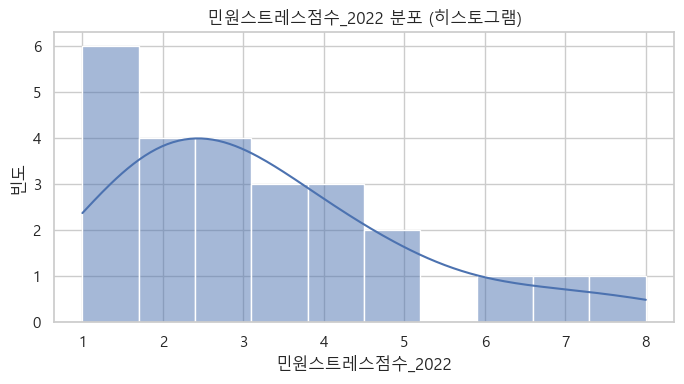

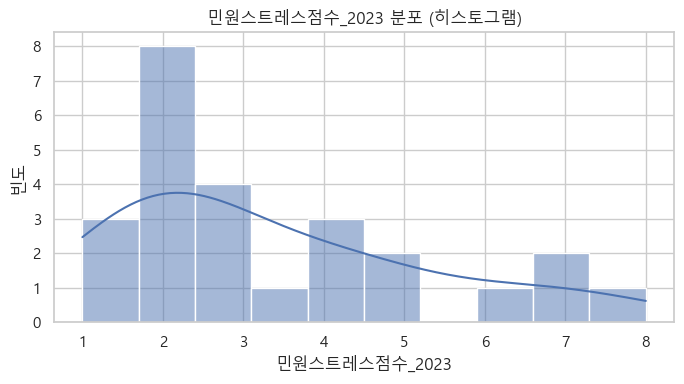

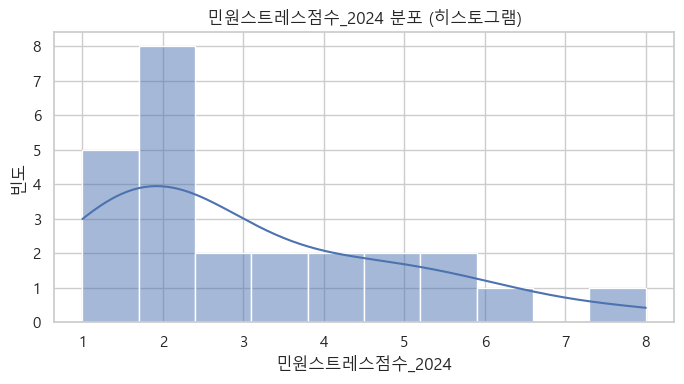

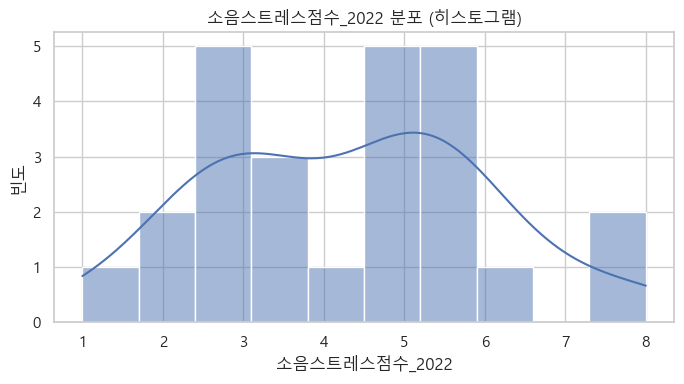

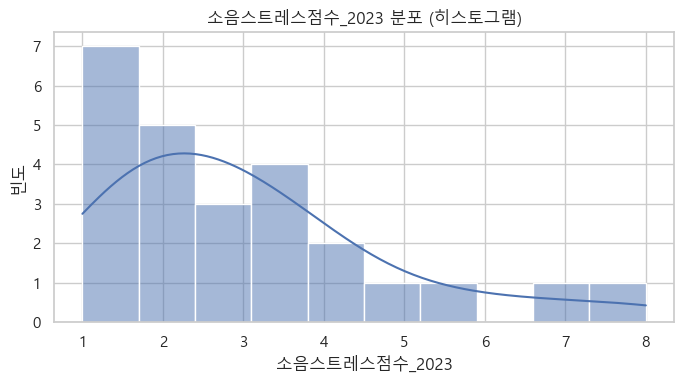

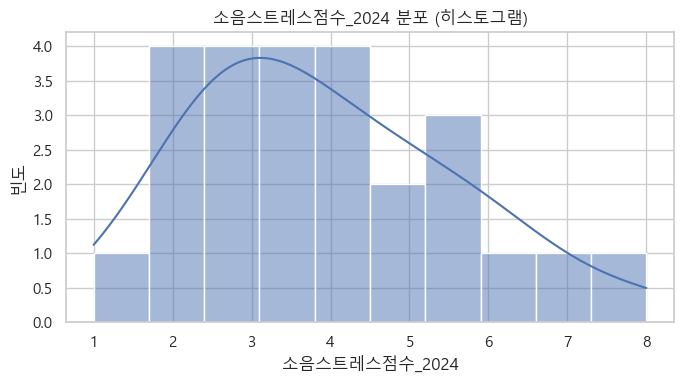

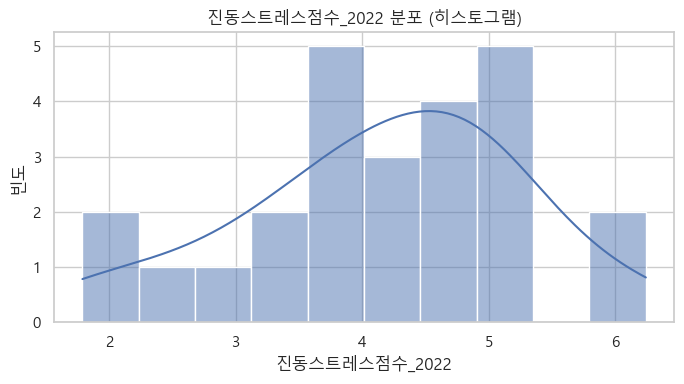

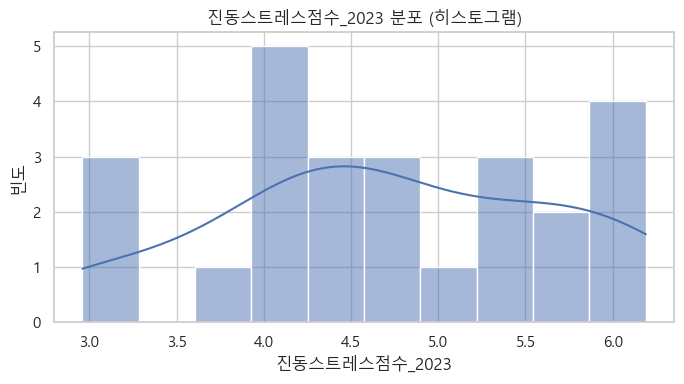

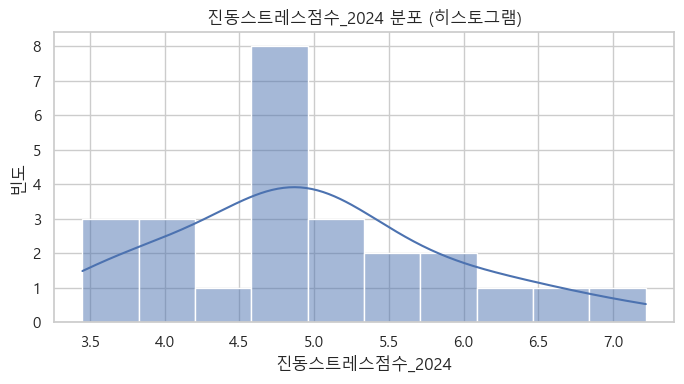

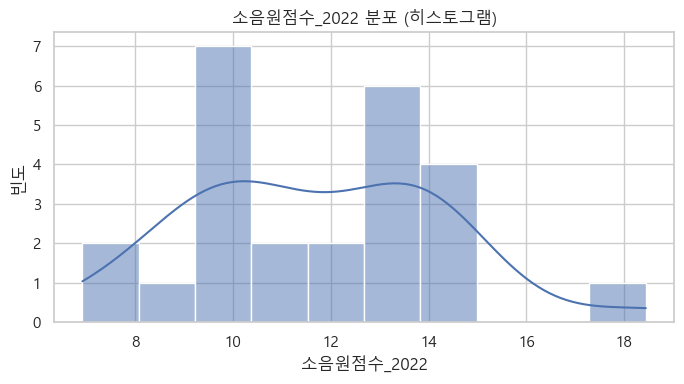

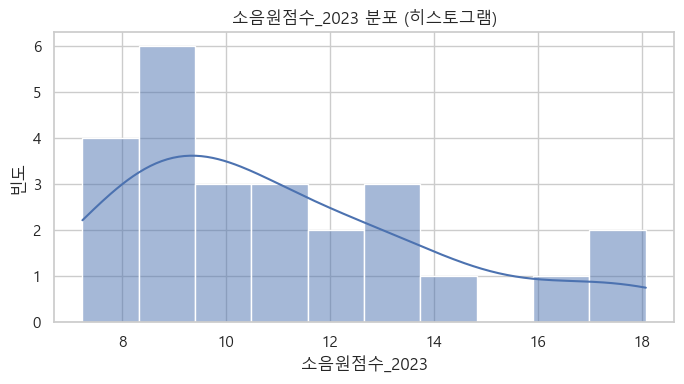

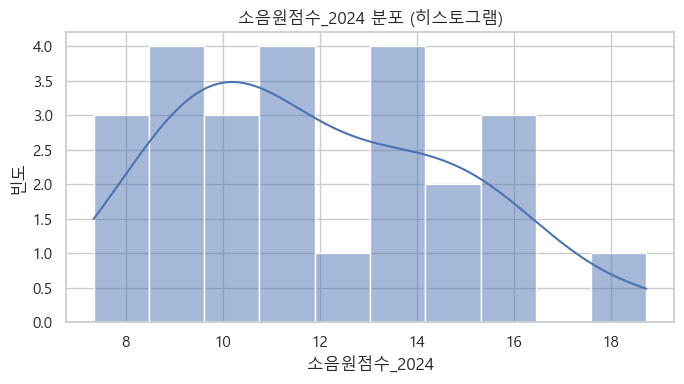

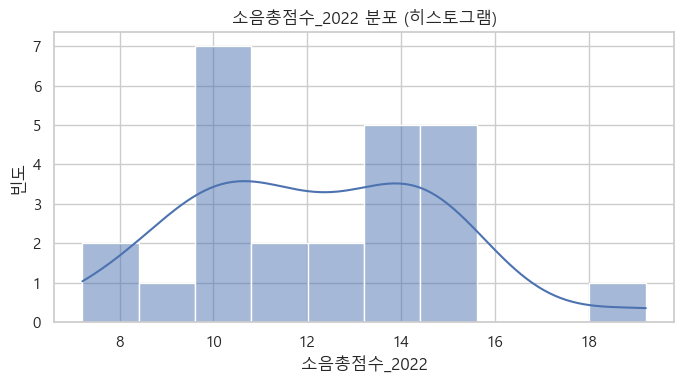

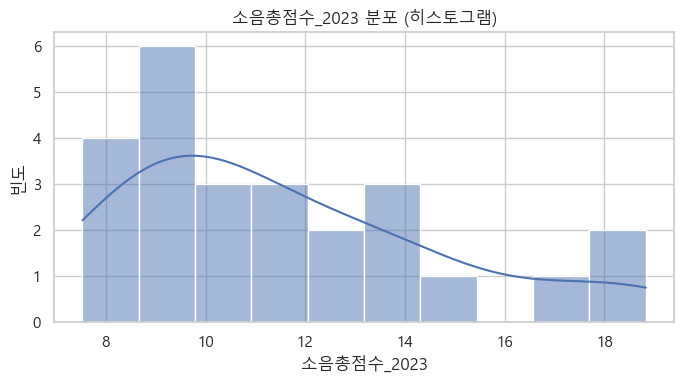

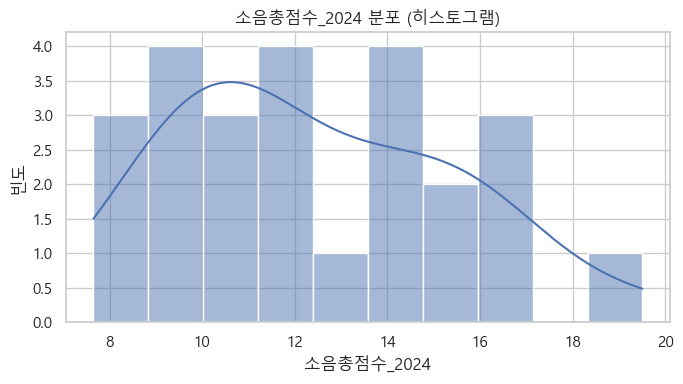

In [13]:
# 목적:
# - 각 점수 컬럼의 분포 모양(치우침, 퍼짐, 봉우리)을 확인

for col in score_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col].dropna(), bins=10, kde=True)
    plt.title(f"{col} 분포 (히스토그램)")
    plt.xlabel(col)
    plt.ylabel("빈도")
    plt.tight_layout()
    plt.show()

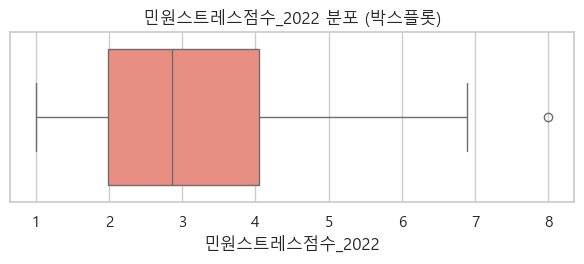

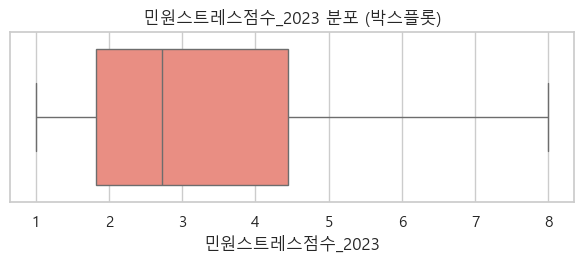

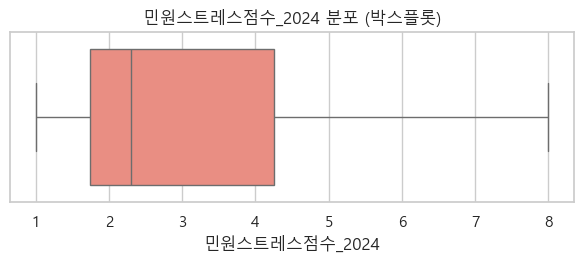

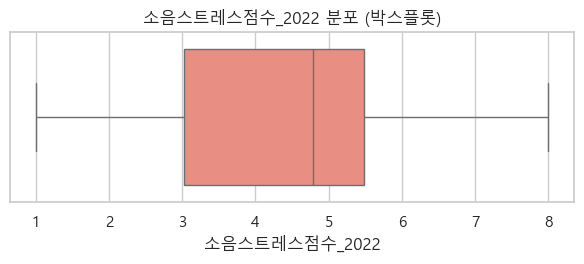

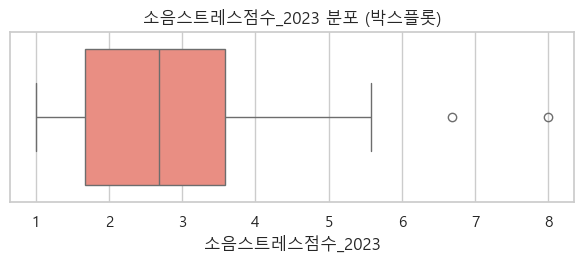

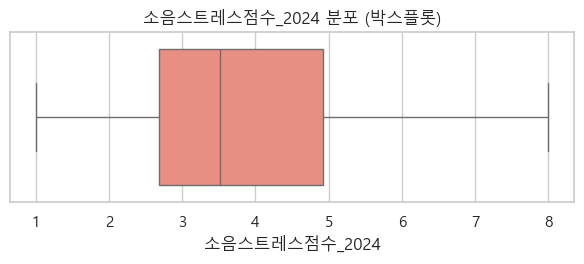

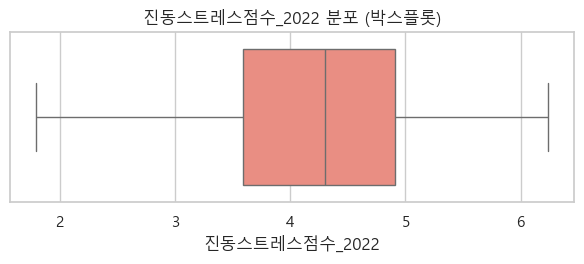

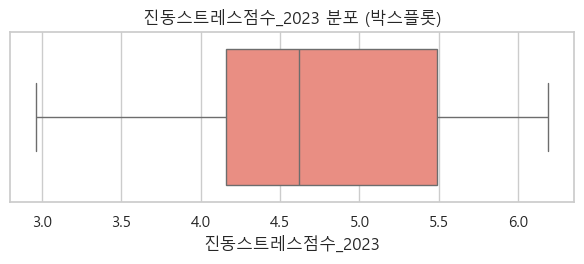

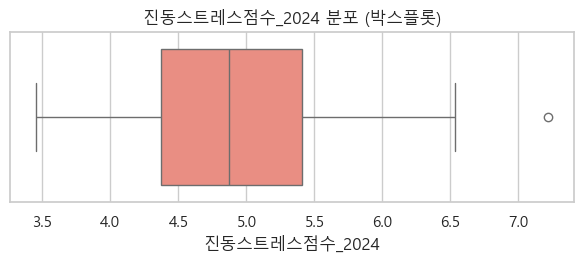

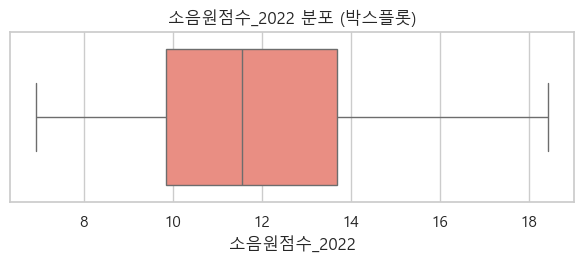

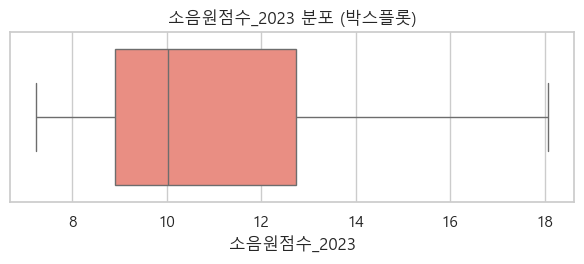

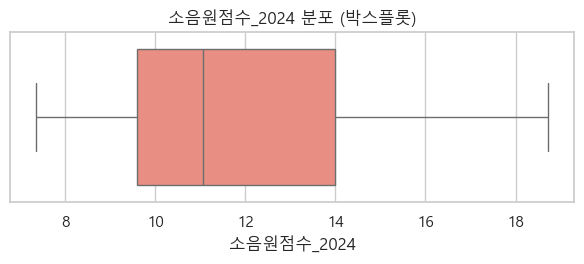

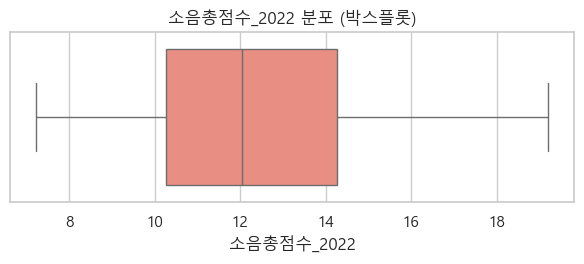

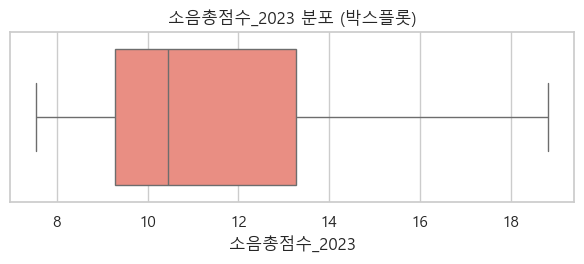

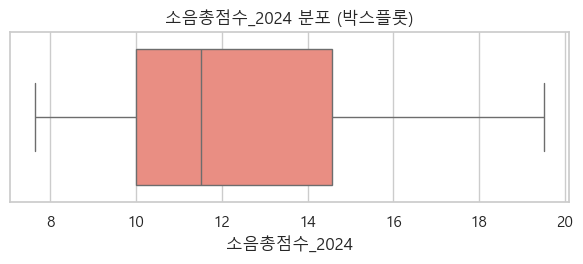

In [14]:
# 목적:
# - 중앙값, 사분위 범위, 이상치 여부를 빠르게 확인

for col in score_cols:
    plt.figure(figsize=(6, 2.8))
    sns.boxplot(x=df[col], color="salmon")
    plt.title(f"{col} 분포 (박스플롯)")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

C:\Users\yiho1\AppData\Local\Temp\ipykernel_39128\324238410.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="연도", y="소음총점수", palette="Purples")


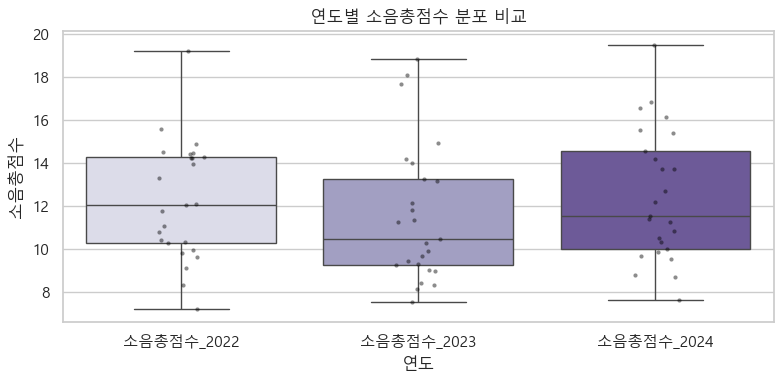

In [15]:
# 목적:
# - 2022~2024 소음총점수 분포를 한 그림에서 비교
# - 연도별 중앙값 이동/분산 변화를 확인

total_cols = [c for c in ["소음총점수_2022", "소음총점수_2023", "소음총점수_2024"] if c in df.columns]
plot_df = df[total_cols].melt(var_name="연도", value_name="소음총점수")

plt.figure(figsize=(8, 4))
sns.boxplot(data=plot_df, x="연도", y="소음총점수", palette="Purples")
sns.stripplot(data=plot_df, x="연도", y="소음총점수", color="black", alpha=0.45, size=3)
plt.title("연도별 소음총점수 분포 비교")
plt.xlabel("연도")
plt.ylabel("소음총점수")
plt.tight_layout()
plt.show()

In [16]:
# 목적:
# - 시각화에서 본 내용을 숫자로 확인(평균, 중앙값, 표준편차)

if len(total_cols) > 0:
    summary = df[total_cols].agg(["mean", "median", "std", "min", "max"]).T
    display(summary)
else:
    print("소음총점수_2022/2023/2024 컬럼을 찾지 못했습니다.")

,mean,median,std,min,max
소음총점수_2022,12.2352,12.04,2.741574,7.21,19.21
소음총점수_2023,11.5800,10.45,3.215920,7.53,18.83
소음총점수_2024,12.4460,11.52,3.044722,7.65,19.51


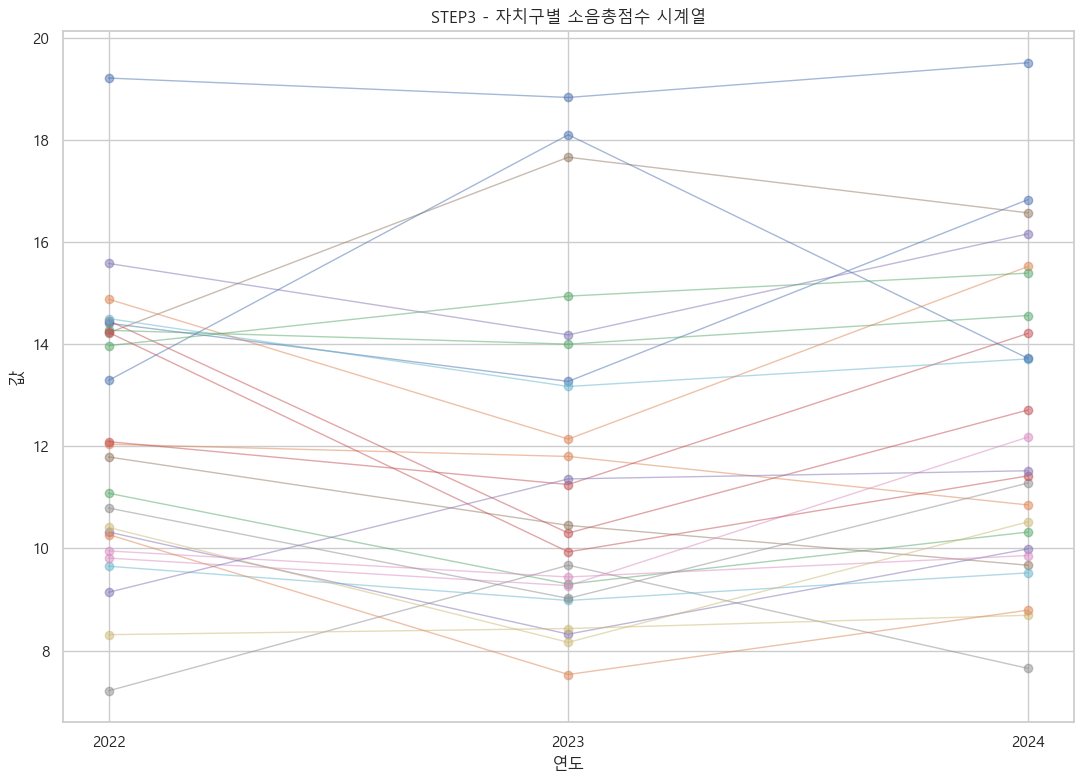

In [17]:
plot_gu_timeseries(
    df,
    value_prefix="소음총점수_",
    title="STEP3 - 자치구별 소음총점수 시계열"
)


## STEP 4. 상관관계 분석 EDA (무엇이 총점에 더 영향을 주는가)

### 목적
- 민원/소음/진동 중 어떤 축이 총점과 더 강하게 연결되는지 확인합니다.
- 연도별로 관계가 달라지는지도 함께 봅니다.

In [18]:
# 분석 대상 컬럼 준비
# 왜:
# - 상관분석은 숫자형 컬럼만 대상으로 해야 의미가 정확합니다.
# - 연도별로 묶어두면 해석할 때 혼동이 줄어듭니다.

component_cols = [
    "민원스트레스점수_2022", "소음스트레스점수_2022", "진동스트레스점수_2022", "소음총점수_2022",
    "민원스트레스점수_2023", "소음스트레스점수_2023", "진동스트레스점수_2023", "소음총점수_2023",
    "민원스트레스점수_2024", "소음스트레스점수_2024", "진동스트레스점수_2024", "소음총점수_2024",
]
component_cols = [c for c in component_cols if c in df.columns]

print("분석 컬럼 수:", len(component_cols))
print(component_cols)

분석 컬럼 수: 12
['민원스트레스점수_2022', '소음스트레스점수_2022', '진동스트레스점수_2022', '소음총점수_2022', '민원스트레스점수_2023', '소음스트레스점수_2023', '진동스트레스점수_2023', '소음총점수_2023', '민원스트레스점수_2024', '소음스트레스점수_2024', '진동스트레스점수_2024', '소음총점수_2024']


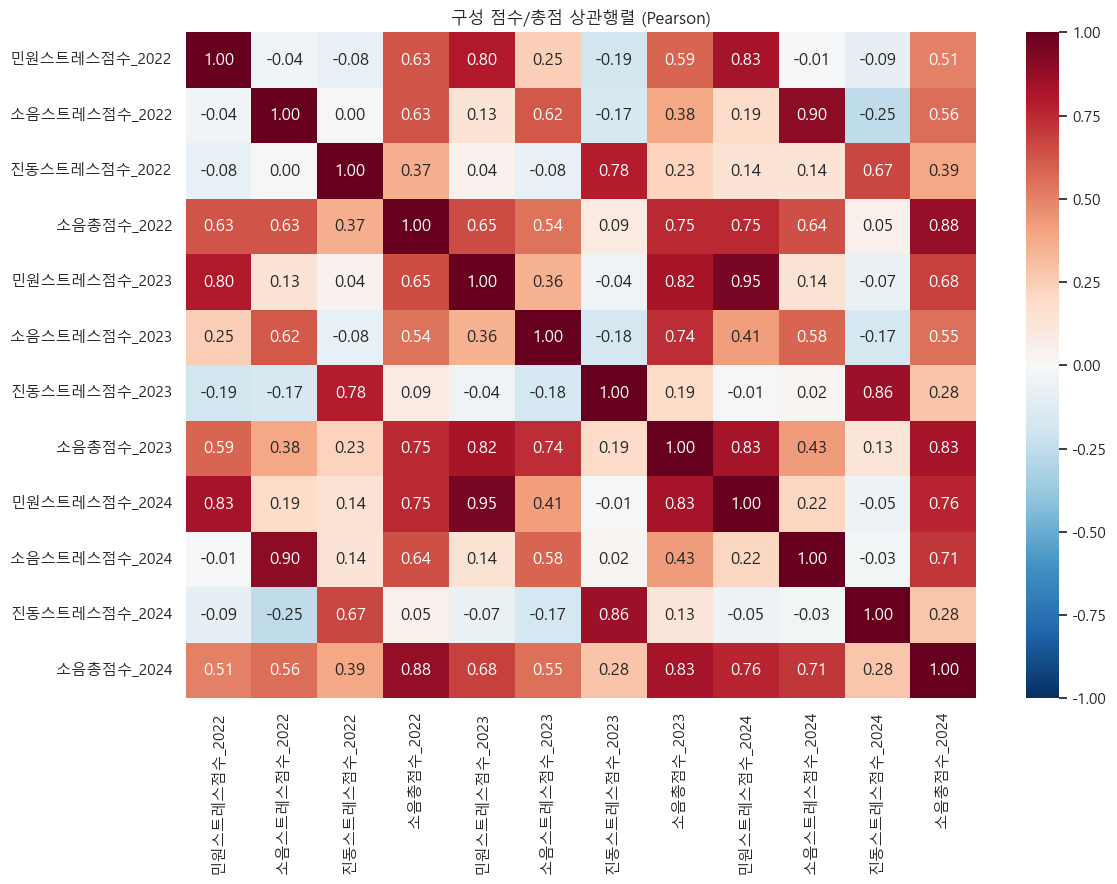

In [19]:
# 전체 상관행렬(피어슨) 확인
# 왜:
# - 전체 구조를 한 번에 보고, 강한 양/음의 관계를 빠르게 찾기 좋습니다.

import seaborn as sns
import matplotlib.pyplot as plt

corr_all = df[component_cols].corr(method="pearson")

plt.figure(figsize=(12, 9))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("구성 점수/총점 상관행렬 (Pearson)")
plt.tight_layout()
plt.show()

In [20]:
# 연도별로 '총점'과 각 구성요소 상관계수만 깔끔히 추출
# 왜:
# - 우리가 궁금한 핵심은 "총점을 많이 설명하는 축이 무엇인가"이기 때문입니다.

years = [2022, 2023, 2024]
rows = []

for y in years:
    total_col = f"소음총점수_{y}"
    cand = [f"민원스트레스점수_{y}", f"소음스트레스점수_{y}", f"진동스트레스점수_{y}", total_col]
    cand = [c for c in cand if c in df.columns]

    if total_col in cand:
        corr = df[cand].corr().loc[total_col].drop(total_col)
        for k, v in corr.items():
            rows.append({"연도": y, "구성요소": k, "총점과상관계수": v})

corr_vs_total = pd.DataFrame(rows)
display(corr_vs_total.sort_values(["연도", "총점과상관계수"], ascending=[True, False]))

,연도,구성요소,총점과상관계수
1,2022,소음스트레스점수_2022,0.631310
0,2022,민원스트레스점수_2022,0.629089
2,2022,진동스트레스점수_2022,0.365823
3,2023,민원스트레스점수_2023,0.821833
4,2023,소음스트레스점수_2023,0.736567
5,2023,진동스트레스점수_2023,0.192335
6,2024,민원스트레스점수_2024,0.763553
7,2024,소음스트레스점수_2024,0.712152
8,2024,진동스트레스점수_2024,0.275028


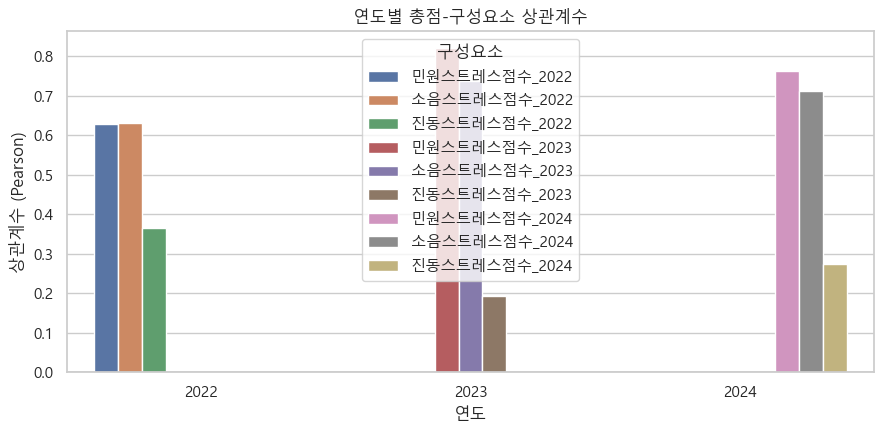

In [21]:
# 연도별 상관계수 막대그래프
# 왜:
# - 숫자표보다 설명/발표에서 어떤 축이 더 큰지 직관적으로 전달됩니다.

plt.figure(figsize=(9, 4.5))
sns.barplot(data=corr_vs_total, x="연도", y="총점과상관계수", hue="구성요소")
plt.axhline(0, color="gray", linewidth=1)
plt.title("연도별 총점-구성요소 상관계수")
plt.ylabel("상관계수 (Pearson)")
plt.xlabel("연도")
plt.tight_layout()
plt.show()

In [22]:
# 참고: 스피어만 상관도 같이 확인(순위 기반, 이상치에 덜 민감)
# 왜:
# - 피어슨은 선형관계에 민감하고, 스피어만은 순위관계에 강합니다.
# - 두 결과를 같이 보면 해석 신뢰도가 올라갑니다.

rows_s = []
for y in years:
    total_col = f"소음총점수_{y}"
    cand = [f"민원스트레스점수_{y}", f"소음스트레스점수_{y}", f"진동스트레스점수_{y}", total_col]
    cand = [c for c in cand if c in df.columns]

    if total_col in cand:
        corr_s = df[cand].corr(method="spearman").loc[total_col].drop(total_col)
        for k, v in corr_s.items():
            rows_s.append({"연도": y, "구성요소": k, "총점과스피어만": v})

corr_vs_total_s = pd.DataFrame(rows_s)
display(corr_vs_total_s.sort_values(["연도", "총점과스피어만"], ascending=[True, False]))

,연도,구성요소,총점과스피어만
1,2022,소음스트레스점수_2022,0.674745
0,2022,민원스트레스점수_2022,0.573572
2,2022,진동스트레스점수_2022,0.309231
3,2023,민원스트레스점수_2023,0.829231
4,2023,소음스트레스점수_2023,0.681285
5,2023,진동스트레스점수_2023,0.180419
7,2024,소음스트레스점수_2024,0.767692
6,2024,민원스트레스점수_2024,0.691538
8,2024,진동스트레스점수_2024,0.309231


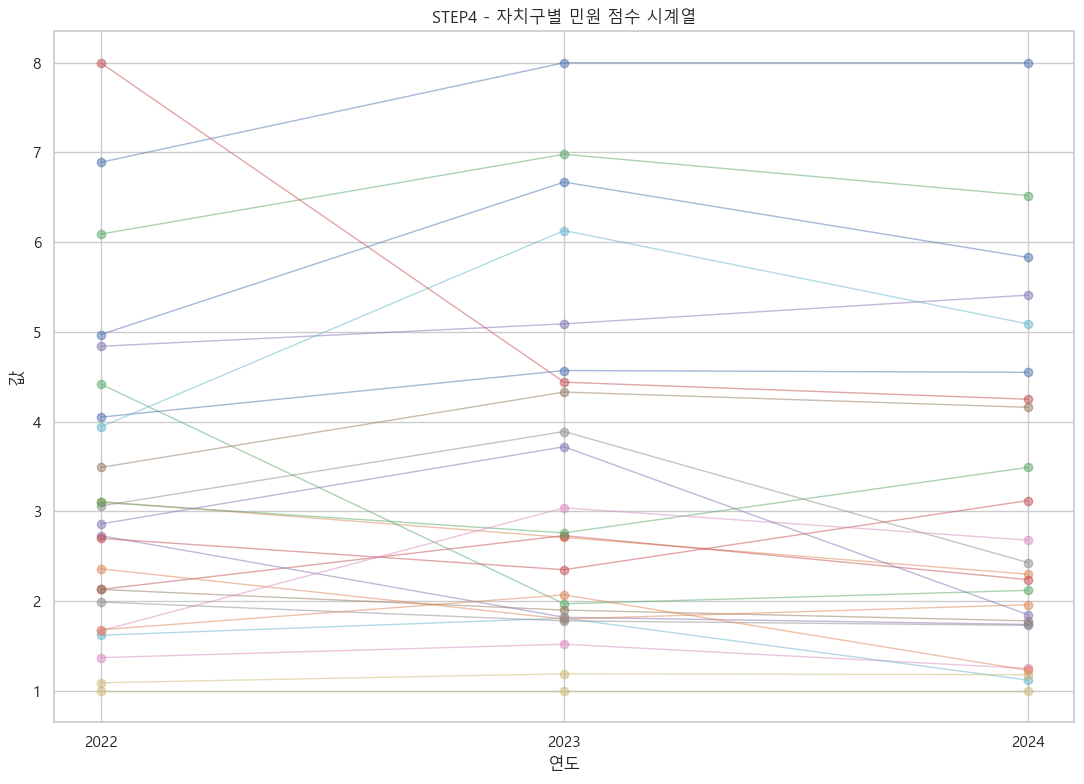

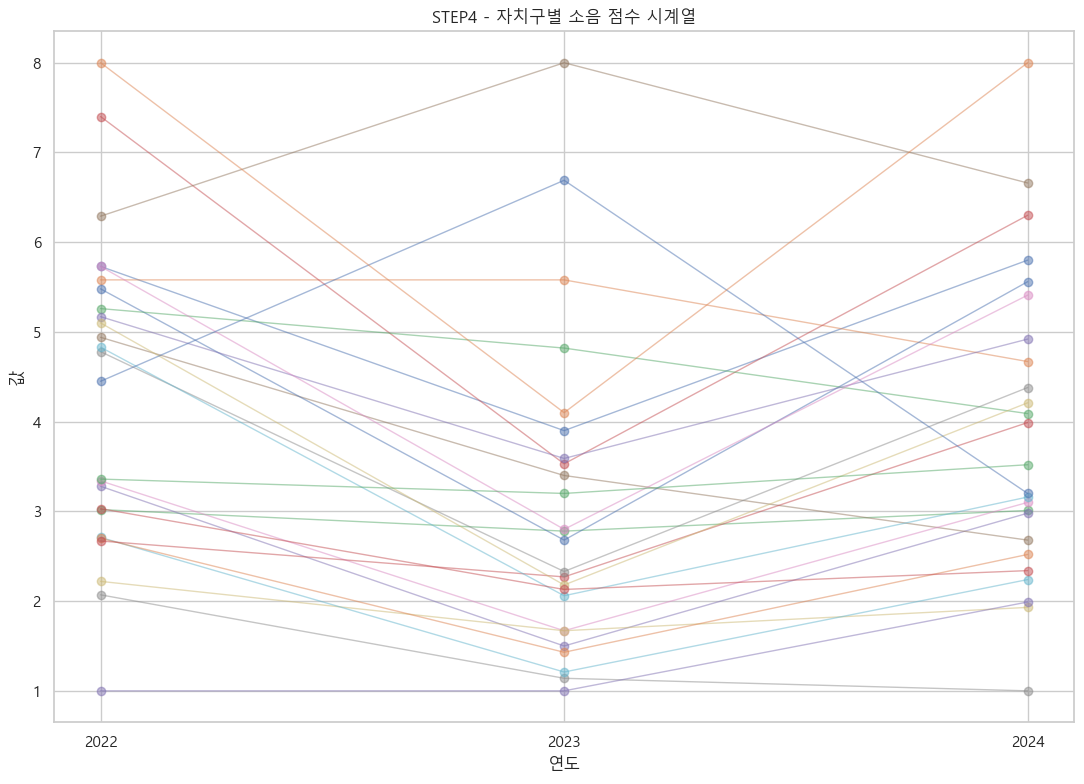

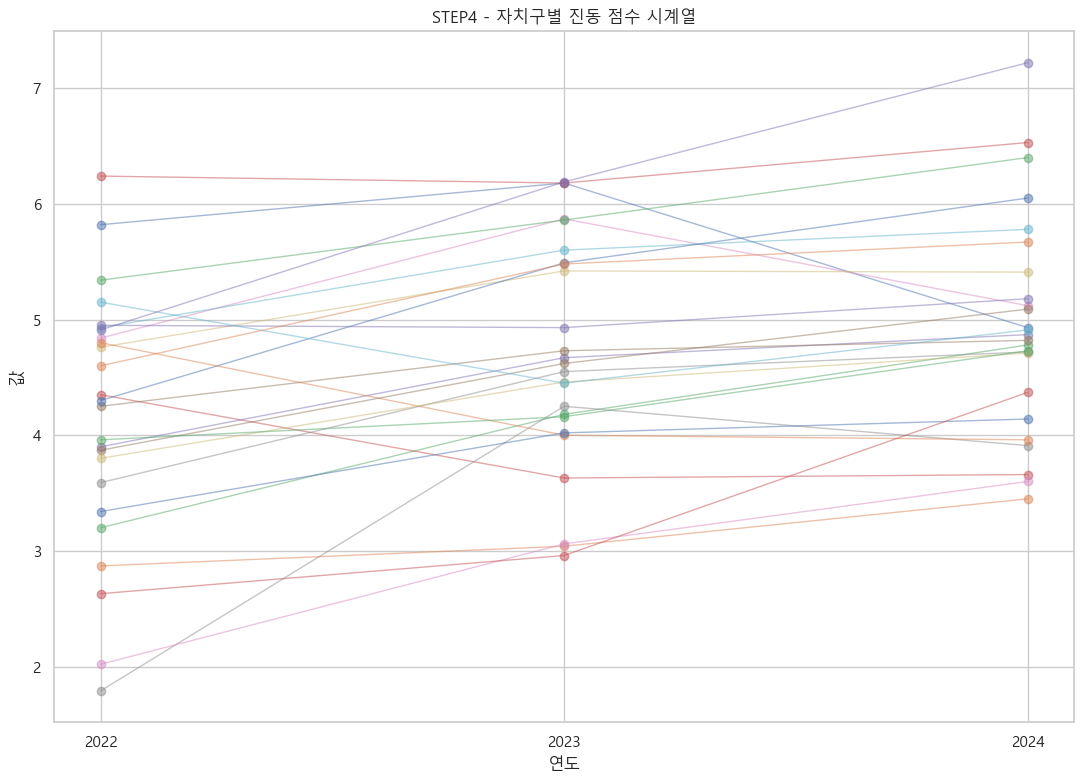

In [23]:
for prefix, name in [
    ("민원스트레스점수_", "민원"),
    ("소음스트레스점수_", "소음"),
    ("진동스트레스점수_", "진동"),
]:
    plot_gu_timeseries(
        df,
        value_prefix=prefix,
        title=f"STEP4 - 자치구별 {name} 점수 시계열"
    )


## STEP 5. 연도별 변화 분석 (증감량/증감률/개선·악화 구 찾기)

### 목적
- 2022→2023, 2023→2024 사이에 어떤 자치구가 가장 악화/개선됐는지 확인합니다.
- 단순 총점 수준(높다/낮다)뿐 아니라 변화 방향(나빠지는 중인지)을 파악합니다.

In [24]:
# 분석용 변화 컬럼 만들기
# 왜:
# - 총점의 절대 변화량과 비율 변화를 같이 봐야 해석이 균형적입니다.

change_df = df.copy()

# 절대 증감량
change_df["증감_22_23"] = change_df["소음총점수_2023"] - change_df["소음총점수_2022"]
change_df["증감_23_24"] = change_df["소음총점수_2024"] - change_df["소음총점수_2023"]

# 증감률(%) = 변화량 / 이전연도
# 분모 0 방지: 0이면 NaN 처리
import numpy as np
change_df["증감률_22_23"] = np.where(
    change_df["소음총점수_2022"] == 0,
    np.nan,
    change_df["증감_22_23"] / change_df["소음총점수_2022"] * 100
)
change_df["증감률_23_24"] = np.where(
    change_df["소음총점수_2023"] == 0,
    np.nan,
    change_df["증감_23_24"] / change_df["소음총점수_2023"] * 100
)

display(change_df.head())


,자치구,민원스트레스점수_2022,민원스트레스점수_2023,민원스트레스점수_2024,소음스트레스점수_2022,소음스트레스점수_2023,소음스트레스점수_2024,진동스트레스점수_2022,진동스트레스점수_2023,진동스트레스점수_2024,소음원점수_2022,소음원점수_2023,소음원점수_2024,소음총점수_2022,소음총점수_2023,소음총점수_2024,증감_22_23,증감_23_24,증감률_22_23,증감률_23_24
0,종로구,6.09,6.98,6.52,3.36,3.20,3.52,3.96,4.16,4.73,13.41,14.34,14.77,13.97,14.94,15.39,0.97,0.45,6.943450,3.012048
1,중구,8.00,4.44,4.25,3.03,2.13,2.34,2.63,2.96,4.37,13.66,9.53,10.96,14.23,9.93,11.42,-4.30,1.49,-30.217850,15.005035
2,용산구,4.97,6.67,5.83,4.45,6.69,3.20,3.34,4.02,4.14,12.76,17.38,13.17,13.29,18.10,13.72,4.81,-4.38,36.192626,-24.198895
3,성동구,3.49,4.33,4.16,6.29,8.00,6.66,3.87,4.62,5.09,13.65,16.95,15.91,14.22,17.66,16.57,3.44,-1.09,24.191280,-6.172140
4,광진구,2.13,1.90,1.78,4.94,3.40,2.68,4.25,4.73,4.82,11.32,10.03,9.28,11.79,10.45,9.67,-1.34,-0.78,-11.365564,-7.464115


In [25]:
# 가장 악화/개선된 자치구 Top N 보기
# 왜:
# - 정책 우선순위 후보(악화 상위)와 벤치마크 후보(개선 상위)를 빠르게 찾기 위해

TOP_N = 5

print("[2022→2023] 악화 Top", TOP_N)
display(change_df.sort_values("증감_22_23", ascending=False)[["자치구", "소음총점수_2022", "소음총점수_2023", "증감_22_23", "증감률_22_23"]].head(TOP_N))

print("[2022→2023] 개선 Top", TOP_N)
display(change_df.sort_values("증감_22_23", ascending=True)[["자치구", "소음총점수_2022", "소음총점수_2023", "증감_22_23", "증감률_22_23"]].head(TOP_N))

print("[2023→2024] 악화 Top", TOP_N)
display(change_df.sort_values("증감_23_24", ascending=False)[["자치구", "소음총점수_2023", "소음총점수_2024", "증감_23_24", "증감률_23_24"]].head(TOP_N))

print("[2023→2024] 개선 Top", TOP_N)
display(change_df.sort_values("증감_23_24", ascending=True)[["자치구", "소음총점수_2023", "소음총점수_2024", "증감_23_24", "증감률_23_24"]].head(TOP_N))


[2022→2023] 악화 Top 5


,자치구,소음총점수_2022,소음총점수_2023,증감_22_23,증감률_22_23
2,용산구,13.29,18.10,4.81,36.192626
3,성동구,14.22,17.66,3.44,24.191280
17,금천구,7.21,9.67,2.46,34.119279
6,중랑구,9.14,11.36,2.22,24.288840
0,종로구,13.97,14.94,0.97,6.943450


[2022→2023] 개선 Top 5


,자치구,소음총점수_2022,소음총점수_2023,증감_22_23,증감률_22_23
1,중구,14.23,9.93,-4.30,-30.217850
15,강서구,14.46,10.30,-4.16,-28.769018
11,은평구,14.88,12.14,-2.74,-18.413978
19,동작구,10.27,7.53,-2.74,-26.679649
14,양천구,10.41,8.16,-2.25,-21.613833


[2023→2024] 악화 Top 5


,자치구,소음총점수_2023,소음총점수_2024,증감_23_24,증감률_23_24
5,동대문구,13.27,16.83,3.56,26.827430
11,은평구,12.14,15.52,3.38,27.841845
12,서대문구,11.25,14.21,2.96,26.311111
7,성북구,9.27,12.18,2.91,31.391586
15,강서구,10.30,12.71,2.41,23.398058


[2023→2024] 개선 Top 5


,자치구,소음총점수_2023,소음총점수_2024,증감_23_24,증감률_23_24
2,용산구,18.10,13.72,-4.38,-24.198895
17,금천구,9.67,7.65,-2.02,-20.889349
3,성동구,17.66,16.57,-1.09,-6.172140
24,강동구,11.80,10.85,-0.95,-8.050847
4,광진구,10.45,9.67,-0.78,-7.464115


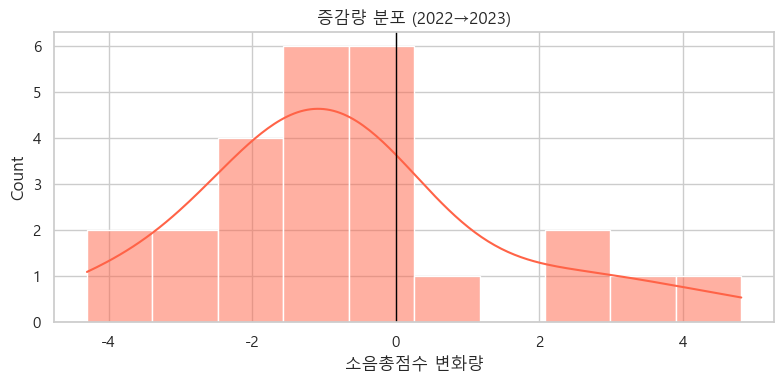

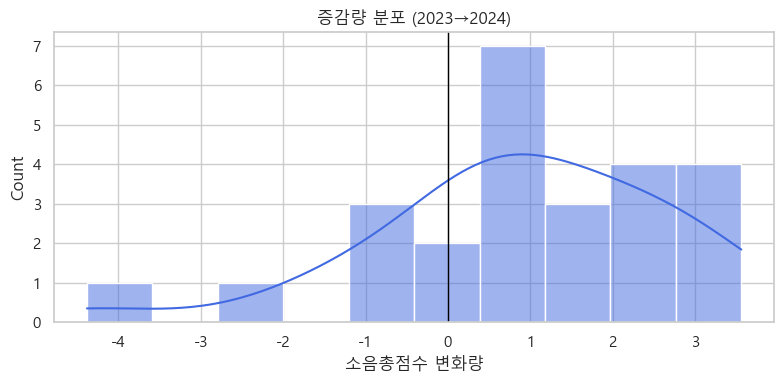

In [26]:
# 변화량 분포 시각화
# 왜:
# - 전체 구가 대체로 악화인지/개선인지, 변화 폭이 큰지 작은지 확인

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(change_df["증감_22_23"], bins=10, kde=True, color="tomato")
plt.axvline(0, color="black", linewidth=1)
plt.title("증감량 분포 (2022→2023)")
plt.xlabel("소음총점수 변화량")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(change_df["증감_23_24"], bins=10, kde=True, color="royalblue")
plt.axvline(0, color="black", linewidth=1)
plt.title("증감량 분포 (2023→2024)")
plt.xlabel("소음총점수 변화량")
plt.tight_layout()
plt.show()

C:\Users\yiho1\AppData\Local\Temp\ipykernel_39128\4027253902.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot1, x="증감_22_23", y="자치구", palette="coolwarm")


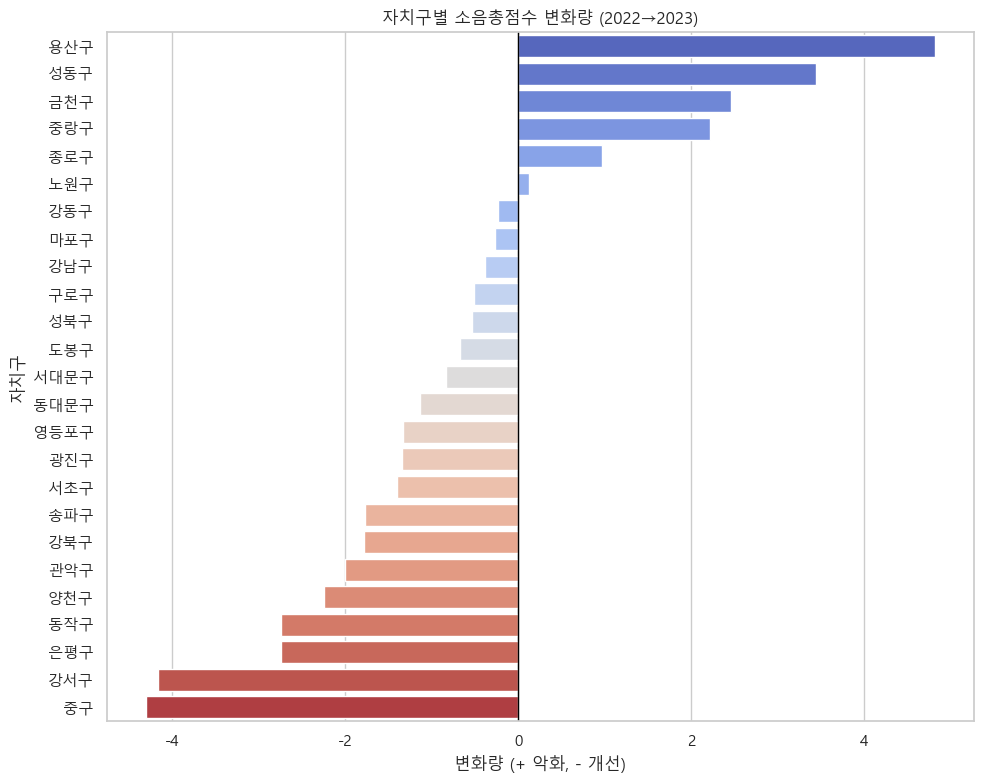

C:\Users\yiho1\AppData\Local\Temp\ipykernel_39128\4027253902.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot2, x="증감_23_24", y="자치구", palette="coolwarm")


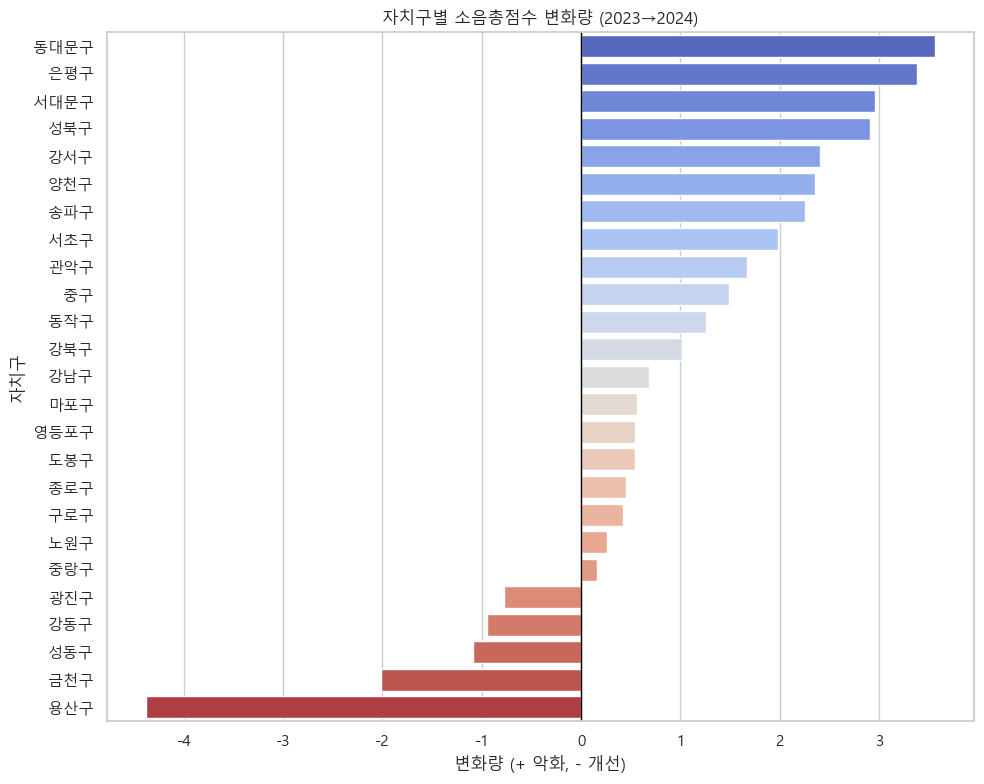

In [27]:
# 자치구별 변화량 막대그래프
# 왜:
# - 어떤 구가 많이 변했는지 순위로 직관적으로 전달하기 위해

plot1 = change_df.sort_values("증감_22_23", ascending=False)
plot2 = change_df.sort_values("증감_23_24", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot1, x="증감_22_23", y="자치구", palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("자치구별 소음총점수 변화량 (2022→2023)")
plt.xlabel("변화량 (+ 악화, - 개선)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.barplot(data=plot2, x="증감_23_24", y="자치구", palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("자치구별 소음총점수 변화량 (2023→2024)")
plt.xlabel("변화량 (+ 악화, - 개선)")
plt.tight_layout()
plt.show()

In [28]:
# 악화/개선 라벨링 (보고서용)
# 왜:
# - 숫자 대신 상태 라벨을 만들어 요약 표/슬라이드에 쓰기 좋게 만듭니다.

def trend_label(x, tol=0.2):
    # tol: 미세 변동(노이즈)을 '유지'로 간주하는 임계치
    if pd.isna(x):
        return "판단불가"
    if x > tol:
        return "악화"
    elif x < -tol:
        return "개선"
    else:
        return "유지"

change_df["추세_22_23"] = change_df["증감_22_23"].apply(trend_label)
change_df["추세_23_24"] = change_df["증감_23_24"].apply(trend_label)

display(change_df[["자치구", "증감_22_23", "추세_22_23", "증감_23_24", "추세_23_24"]].head(10))
print("22→23 추세 분포")
print(change_df["추세_22_23"].value_counts())
print("\n23→24 추세 분포")
print(change_df["추세_23_24"].value_counts())

,자치구,증감_22_23,추세_22_23,증감_23_24,추세_23_24
0,종로구,0.97,악화,0.45,악화
1,중구,-4.30,개선,1.49,악화
2,용산구,4.81,악화,-4.38,개선
3,성동구,3.44,악화,-1.09,개선
4,광진구,-1.34,개선,-0.78,개선
5,동대문구,-1.14,개선,3.56,악화
6,중랑구,2.22,악화,0.16,유지
7,성북구,-0.54,개선,2.91,악화
8,강북구,-1.78,개선,1.02,악화
9,도봉구,-0.67,개선,0.54,악화


22→23 추세 분포
추세_22_23
개선    19
악화     5
유지     1
Name: count, dtype: int64

23→24 추세 분포
추세_23_24
악화    19
개선     5
유지     1
Name: count, dtype: int64


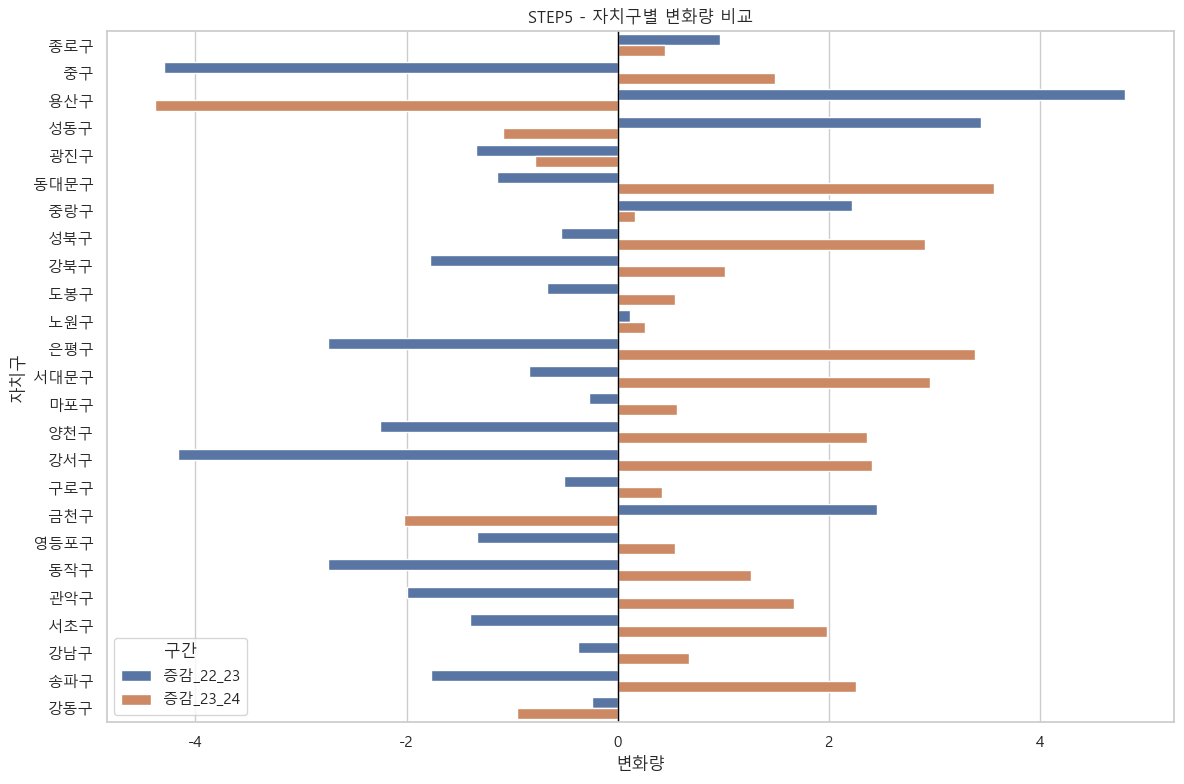

In [29]:
chg = df.copy()
chg["증감_22_23"] = chg["소음총점수_2023"] - chg["소음총점수_2022"]
chg["증감_23_24"] = chg["소음총점수_2024"] - chg["소음총점수_2023"]

plot_chg = chg.melt(id_vars="자치구", value_vars=["증감_22_23", "증감_23_24"], var_name="구간", value_name="변화량")

plt.figure(figsize=(12, 8))
sns.barplot(data=plot_chg, x="변화량", y="자치구", hue="구간")
plt.axvline(0, color="black", linewidth=1)
plt.title("STEP5 - 자치구별 변화량 비교")
plt.tight_layout()
plt.show()


## STEP 6. 순위 안정성 분석 (랭크 변동폭 확인)

### 목적
- 단순 점수 수준이 아니라, 연도별 순위가 얼마나 흔들리는지 확인합니다.
- 항상 높은 구(구조적 고위험) vs 일시적으로 튄 구(일시 변동)를 구분합니다

In [30]:
# 연도별 순위 컬럼 생성
# 왜:
# - 총점 자체와 별개로 "상대적 위치"를 보기 위해 순위를 만듭니다.
# - method='min': 동점이면 같은 최소 순위 부여

rank_df = df.copy()

rank_df["rank_2022"] = rank_df["소음총점수_2022"].rank(ascending=False, method="min")
rank_df["rank_2023"] = rank_df["소음총점수_2023"].rank(ascending=False, method="min")
rank_df["rank_2024"] = rank_df["소음총점수_2024"].rank(ascending=False, method="min")

display(rank_df[["자치구", "소음총점수_2022", "rank_2022", "소음총점수_2023", "rank_2023", "소음총점수_2024", "rank_2024"]].head())


,자치구,소음총점수_2022,rank_2022,소음총점수_2023,rank_2023,소음총점수_2024,rank_2024
0,종로구,13.97,10.0,14.94,4.0,15.39,6.0
1,중구,14.23,8.0,9.93,15.0,11.42,14.0
2,용산구,13.29,11.0,18.10,2.0,13.72,9.0
3,성동구,14.22,9.0,17.66,3.0,16.57,3.0
4,광진구,11.79,14.0,10.45,13.0,9.67,21.0


In [31]:
# 순위 변화량 계산
# 왜:
# - 순위가 얼마나 바뀌었는지 숫자로 측정해야 안정/불안정 구분이 가능합니다.
# - rank 값은 작을수록 높은 순위이므로, (이전 - 이후) > 0이면 순위 상승입니다.

rank_df["rank_change_22_23"] = rank_df["rank_2022"] - rank_df["rank_2023"]  # +면 상승
rank_df["rank_change_23_24"] = rank_df["rank_2023"] - rank_df["rank_2024"]  # +면 상승

# 3개년 전체 변동폭(최대순위-최소순위): 작을수록 안정적
rank_df["rank_range_3y"] = rank_df[["rank_2022", "rank_2023", "rank_2024"]].max(axis=1) - rank_df[["rank_2022", "rank_2023", "rank_2024"]].min(axis=1)

# 연속연도 변동 절대합: 클수록 요동이 큰 구
rank_df["rank_volatility"] = rank_df["rank_change_22_23"].abs() + rank_df["rank_change_23_24"].abs()

display(rank_df[["자치구", "rank_2022", "rank_2023", "rank_2024", "rank_change_22_23", "rank_change_23_24", "rank_range_3y", "rank_volatility"]].head())


,자치구,rank_2022,rank_2023,rank_2024,rank_change_22_23,rank_change_23_24,rank_range_3y,rank_volatility
0,종로구,10.0,4.0,6.0,6.0,-2.0,6.0,8.0
1,중구,8.0,15.0,14.0,-7.0,1.0,7.0,8.0
2,용산구,11.0,2.0,9.0,9.0,-7.0,9.0,16.0
3,성동구,9.0,3.0,3.0,6.0,0.0,6.0,6.0
4,광진구,14.0,13.0,21.0,1.0,-8.0,8.0,9.0


In [32]:
# 안정/불안정 TOP 보기
# 왜:
# - 실무적으로는 "가장 안정적/가장 흔들리는 구"를 바로 보는 것이 유용합니다.

TOP_N = 7

print("순위가 가장 안정적인 구 TOP", TOP_N, "(rank_range_3y 작은 순)")
display(
    rank_df.sort_values(["rank_range_3y", "rank_volatility"], ascending=[True, True])[
        ["자치구", "rank_2022", "rank_2023", "rank_2024", "rank_range_3y", "rank_volatility"]
    ].head(TOP_N)
)

print("순위 변동이 큰 구 TOP", TOP_N, "(rank_volatility 큰 순)")
display(
    rank_df.sort_values(["rank_volatility", "rank_range_3y"], ascending=[False, False])[
        ["자치구", "rank_2022", "rank_2023", "rank_2024", "rank_range_3y", "rank_volatility"]
    ].head(TOP_N)
)


순위가 가장 안정적인 구 TOP 7 (rank_range_3y 작은 순)


,자치구,rank_2022,rank_2023,rank_2024,rank_range_3y,rank_volatility
22,강남구,1.0,1.0,1.0,0.0,0.0
9,도봉구,22.0,21.0,22.0,1.0,2.0
13,마포구,7.0,6.0,7.0,1.0,2.0
10,노원구,24.0,22.0,24.0,2.0,4.0
8,강북구,15.0,18.0,18.0,3.0,3.0
21,서초구,2.0,5.0,4.0,3.0,4.0
16,구로구,20.0,17.0,20.0,3.0,6.0


순위 변동이 큰 구 TOP 7 (rank_volatility 큰 순)


,자치구,rank_2022,rank_2023,rank_2024,rank_range_3y,rank_volatility
17,금천구,25.0,16.0,25.0,9.0,18.0
2,용산구,11.0,2.0,9.0,9.0,16.0
6,중랑구,23.0,11.0,13.0,12.0,14.0
14,양천구,17.0,24.0,17.0,7.0,14.0
15,강서구,5.0,14.0,11.0,9.0,12.0
11,은평구,3.0,9.0,5.0,6.0,10.0
7,성북구,21.0,19.0,12.0,9.0,9.0


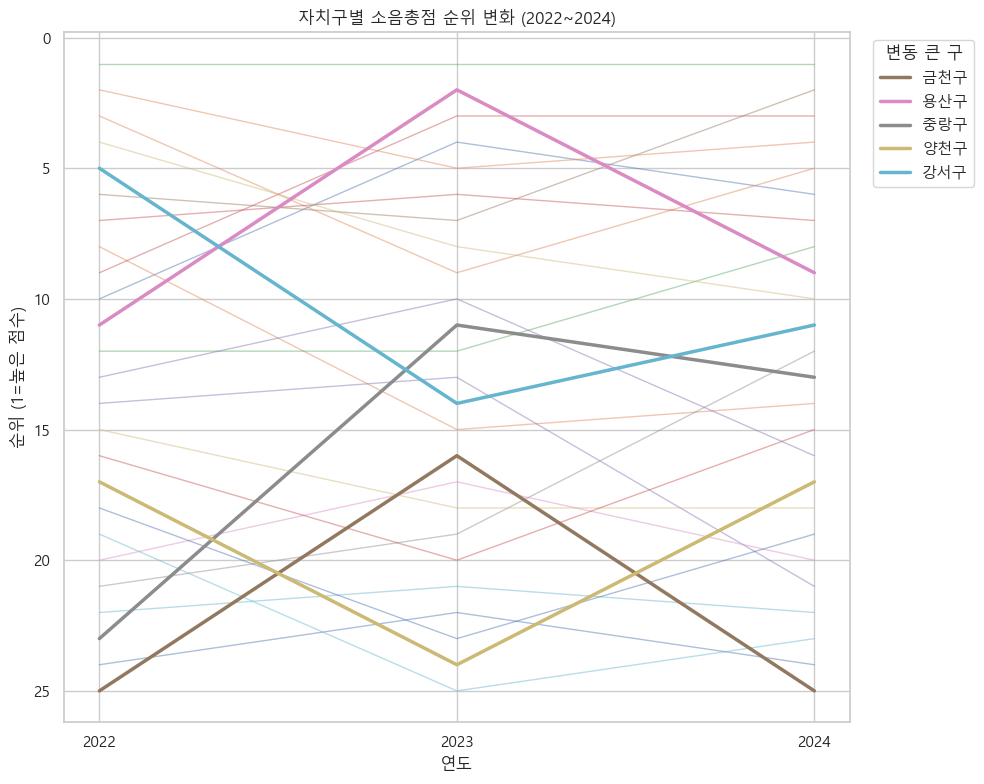

In [33]:
# 연도별 순위 스파게티 플롯
# 왜:
# - 표보다 선 그래프가 순위 이동 경로를 직관적으로 보여줍니다.

import matplotlib.pyplot as plt

years = [2022, 2023, 2024]
plt.figure(figsize=(10, 8))

for _, row in rank_df.iterrows():
    yvals = [row["rank_2022"], row["rank_2023"], row["rank_2024"]]
    plt.plot(years, yvals, alpha=0.45, linewidth=1)

# 변동 큰 구는 라벨 강조 (상위 5개)
top_vol = rank_df.sort_values("rank_volatility", ascending=False).head(5)
for _, row in top_vol.iterrows():
    yvals = [row["rank_2022"], row["rank_2023"], row["rank_2024"]]
    plt.plot(years, yvals, linewidth=2.5, label=row["자치구"])

plt.gca().invert_yaxis()  # 1등이 위로 오게
plt.xticks(years)
plt.title("자치구별 소음총점 순위 변화 (2022~2024)")
plt.xlabel("연도")
plt.ylabel("순위 (1=높은 점수)")
plt.legend(title="변동 큰 구", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


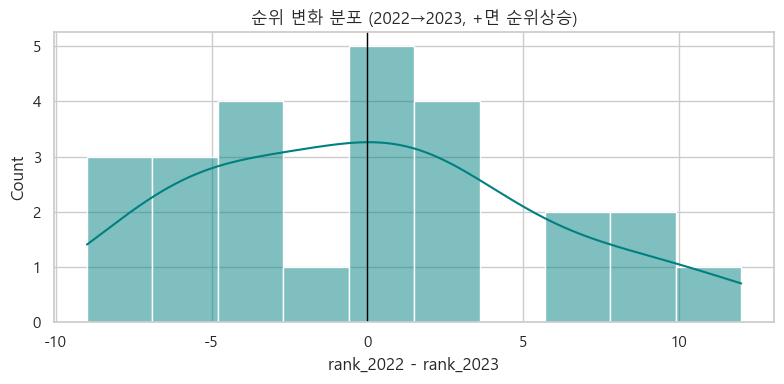

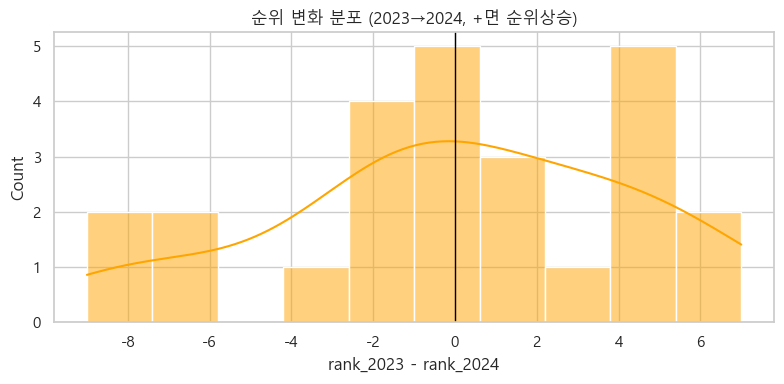

In [34]:
# [STEP 6-5] 순위 이동량 분포 확인
# 왜:
# - 전체적으로 순위가 안정적인지(0 근처), 많이 이동하는지(양끝 분산)를 확인

import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(rank_df["rank_change_22_23"], bins=10, kde=True, color="teal")
plt.axvline(0, color="black", linewidth=1)
plt.title("순위 변화 분포 (2022→2023, +면 순위상승)")
plt.xlabel("rank_2022 - rank_2023")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(rank_df["rank_change_23_24"], bins=10, kde=True, color="orange")
plt.axvline(0, color="black", linewidth=1)
plt.title("순위 변화 분포 (2023→2024, +면 순위상승)")
plt.xlabel("rank_2023 - rank_2024")
plt.tight_layout()
plt.show()


In [35]:
# STEP 7에서 쓸 수 있게 저장(선택)
# 왜:
# - 다음 단계에서 rank_df를 그대로 재활용하면 편합니다.

rank_df.to_csv("소음최종점수_with_rank.csv", index=False, encoding="utf-8-sig")
print("STEP 6 완료")


STEP 6 완료


## STEP 7. 점수 산식 민감도 분석 (가중치 바꾸면 결과가 얼마나 달라지나)

### 목적
- 현재 총점은 민원/소음/진동을 동일 가중치로 합산합니다.
- 가중치를 바꿨을 때 순위가 크게 뒤집히는지 확인해 지표의 안정성을 점검합니다.


In [36]:
# 분석 데이터 준비
# 왜:
# - 민감도 분석은 구성요소(민원/소음/진동)와 총점을 같은 테이블에서 다뤄야 합니다.
# - 여기서는 2024년을 기준으로 예시(원하면 2022/2023도 동일 방식 반복 가능)

sens_df = df.copy()

required_2024 = ["자치구", "민원스트레스점수_2024", "소음스트레스점수_2024", "진동스트레스점수_2024", "소음총점수_2024"]
missing = [c for c in required_2024 if c not in sens_df.columns]
if missing:
    raise ValueError(f"필수 컬럼 누락: {missing}")

display(sens_df[required_2024].head())


,자치구,민원스트레스점수_2024,소음스트레스점수_2024,진동스트레스점수_2024,소음총점수_2024
0,종로구,6.52,3.52,4.73,15.39
1,중구,4.25,2.34,4.37,11.42
2,용산구,5.83,3.20,4.14,13.72
3,성동구,4.16,6.66,5.09,16.57
4,광진구,1.78,2.68,4.82,9.67


In [37]:
# 시나리오(가중치 세트) 정의
# 왜:
# - 어떤 정책 관점을 더 중시할지에 따라 가중치를 달리 줄 수 있습니다.
# - 합계는 1.0으로 맞춰야 점수 스케일 비교가 공정합니다.

# 각 튜플: (민원, 소음, 진동)
weight_scenarios = {
    "기준(동일가중치)": (1/3, 1/3, 1/3),
    "민원강조":        (0.50, 0.30, 0.20),
    "소음강조":        (0.20, 0.60, 0.20),
    "진동강조":        (0.20, 0.30, 0.50),
    "계측중심(소음+진동)": (0.15, 0.55, 0.30),
}

for k, v in weight_scenarios.items():
    print(k, "=>", v, "합:", round(sum(v), 4))


기준(동일가중치) => (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) 합: 1.0
민원강조 => (0.5, 0.3, 0.2) 합: 1.0
소음강조 => (0.2, 0.6, 0.2) 합: 1.0
진동강조 => (0.2, 0.3, 0.5) 합: 1.0
계측중심(소음+진동) => (0.15, 0.55, 0.3) 합: 1.0


In [38]:
# 시나리오별 점수 계산 + 순위 계산
# 왜:
# - "가중치 변경 -> 점수/순위 변화"를 숫자로 확인하려면 각 시나리오 점수를 모두 계산해야 합니다.

for scenario, (w_civil, w_noise, w_vib) in weight_scenarios.items():
    score_col = f"시나리오점수_2024__{scenario}"
    rank_col = f"시나리오순위_2024__{scenario}"

    # 1~8 스케일 구성점수의 가중평균
    sens_df[score_col] = (
        sens_df["민원스트레스점수_2024"] * w_civil +
        sens_df["소음스트레스점수_2024"] * w_noise +
        sens_df["진동스트레스점수_2024"] * w_vib
    )

    # 순위: 점수 높을수록 1등
    sens_df[rank_col] = sens_df[score_col].rank(ascending=False, method="min")

# 기준 순위(원래 총점 기준)도 같이 계산
sens_df["기존순위_2024"] = sens_df["소음총점수_2024"].rank(ascending=False, method="min")

display(sens_df.filter(regex="자치구|기존순위_2024|시나리오순위_2024").head())


,자치구,시나리오순위_2024__기준(동일가중치),시나리오순위_2024__민원강조,시나리오순위_2024__소음강조,시나리오순위_2024__진동강조,시나리오순위_2024__계측중심(소음+진동),기존순위_2024
0,종로구,6.0,2.0,9.0,8.0,10.0,6.0
1,중구,14.0,12.0,18.0,18.0,20.0,14.0
2,용산구,9.0,6.0,13.0,11.0,15.0,9.0
3,성동구,3.0,5.0,3.0,4.0,3.0,3.0
4,광진구,21.0,20.0,21.0,22.0,21.0,21.0


In [39]:
# 기존 순위 대비 변동폭 계산
# 왜:
# - 민감도 핵심은 "가중치 바꿨을 때 순위가 얼마나 흔들리나"입니다.
# - 변동폭이 작으면 지표가 안정적, 크면 가중치 의존성이 큽니다.

change_rows = []

for scenario in weight_scenarios.keys():
    rank_col = f"시나리오순위_2024__{scenario}"
    diff_col = f"순위변화__{scenario}"  # +면 기존보다 순위 상승(숫자 작아짐)
    
    sens_df[diff_col] = sens_df["기존순위_2024"] - sens_df[rank_col]

    change_rows.append({
        "시나리오": scenario,
        "평균절대순위변화": sens_df[diff_col].abs().mean(),
        "최대절대순위변화": sens_df[diff_col].abs().max(),
        "순위상승구수": (sens_df[diff_col] > 0).sum(),
        "순위하락구수": (sens_df[diff_col] < 0).sum(),
        "순위유지구수": (sens_df[diff_col] == 0).sum(),
    })

sensitivity_summary = pd.DataFrame(change_rows).sort_values("평균절대순위변화", ascending=False)
display(sensitivity_summary)


,시나리오,평균절대순위변화,최대절대순위변화,순위상승구수,순위하락구수,순위유지구수
2,소음강조,2.32,7.0,8,10,7
4,계측중심(소음+진동),2.00,6.0,7,8,10
3,진동강조,1.76,6.0,9,12,4
1,민원강조,1.52,4.0,10,11,4
0,기준(동일가중치),0.00,0.0,0,0,25


In [40]:
# 시나리오별 순위 상관(스피어만) 비교
# 왜:
# - 순위 상관이 높으면(1에 가까우면) 시나리오가 달라도 순서가 크게 안 바뀐다는 뜻입니다.

from scipy.stats import spearmanr

corr_rows = []
base_rank = sens_df["기존순위_2024"]

for scenario in weight_scenarios.keys():
    rank_col = f"시나리오순위_2024__{scenario}"
    rho, pval = spearmanr(base_rank, sens_df[rank_col])
    corr_rows.append({
        "시나리오": scenario,
        "기존순위와 스피어만rho": rho,
        "p-value": pval
    })

rank_corr_df = pd.DataFrame(corr_rows).sort_values("기존순위와 스피어만rho")
display(rank_corr_df)


,시나리오,기존순위와 스피어만rho,p-value
2,소음강조,0.910000,2.880369e-10
4,계측중심(소음+진동),0.923077,5.055482e-11
3,진동강조,0.947692,6.772157e-13
1,민원강조,0.965385,6.406769e-15
0,기준(동일가중치),1.000000,0.000000e+00


In [41]:
# 변동이 큰 자치구 확인
# 왜:
# - 전체 평균도 중요하지만, 실제 의사결정에서는 "어느 구가 민감한가"가 더 중요합니다.

# 모든 시나리오의 절대 순위변화 합계(클수록 민감)
diff_cols = [f"순위변화__{s}" for s in weight_scenarios.keys()]
sens_df["총민감도(절대변화합)"] = sens_df[diff_cols].abs().sum(axis=1)

volatile_top = sens_df.sort_values("총민감도(절대변화합)", ascending=False)[
    ["자치구", "기존순위_2024", "총민감도(절대변화합)"] + diff_cols
].head(10)

stable_top = sens_df.sort_values("총민감도(절대변화합)", ascending=True)[
    ["자치구", "기존순위_2024", "총민감도(절대변화합)"] + diff_cols
].head(10)

print("가중치 변경에 민감한 자치구 TOP 10")
display(volatile_top)

print("가중치 변경에 안정적인 자치구 TOP 10")
display(stable_top)


가중치 변경에 민감한 자치구 TOP 10


,자치구,기존순위_2024,총민감도(절대변화합),순위변화__기준(동일가중치),순위변화__민원강조,순위변화__소음강조,순위변화__진동강조,순위변화__계측중심(소음+진동)
6,중랑구,13.0,17.0,0.0,-3.0,-7.0,4.0,-3.0
1,중구,14.0,16.0,0.0,2.0,-4.0,-4.0,-6.0
2,용산구,9.0,15.0,0.0,3.0,-4.0,-2.0,-6.0
24,강동구,16.0,15.0,0.0,2.0,5.0,-5.0,3.0
11,은평구,5.0,14.0,0.0,-4.0,4.0,2.0,4.0
0,종로구,6.0,13.0,0.0,4.0,-3.0,-2.0,-4.0
15,강서구,11.0,11.0,0.0,0.0,5.0,-1.0,5.0
7,성북구,12.0,11.0,0.0,-1.0,5.0,-2.0,3.0
16,구로구,20.0,10.0,0.0,-1.0,3.0,3.0,3.0
18,영등포구,10.0,9.0,0.0,3.0,-4.0,0.0,-2.0


가중치 변경에 안정적인 자치구 TOP 10


,자치구,기존순위_2024,총민감도(절대변화합),순위변화__기준(동일가중치),순위변화__민원강조,순위변화__소음강조,순위변화__진동강조,순위변화__계측중심(소음+진동)
20,관악구,19.0,1.0,0.0,0.0,0.0,-1.0,0.0
17,금천구,25.0,1.0,0.0,1.0,0.0,0.0,0.0
4,광진구,21.0,2.0,0.0,1.0,0.0,-1.0,0.0
10,노원구,24.0,2.0,0.0,-1.0,0.0,1.0,0.0
19,동작구,23.0,2.0,0.0,1.0,0.0,-1.0,0.0
22,강남구,1.0,2.0,0.0,0.0,-1.0,0.0,-1.0
13,마포구,7.0,3.0,0.0,-1.0,-1.0,1.0,0.0
3,성동구,3.0,3.0,0.0,-2.0,0.0,-1.0,0.0
8,강북구,18.0,4.0,0.0,1.0,2.0,-1.0,0.0
21,서초구,4.0,4.0,0.0,1.0,-1.0,-1.0,-1.0


C:\Users\yiho1\AppData\Local\Temp\ipykernel_39128\2806571469.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sensitivity_summary, x="시나리오", y="평균절대순위변화", palette="Set2")


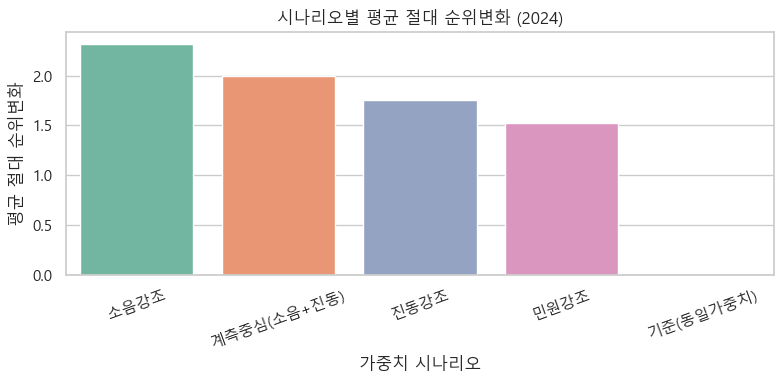

In [42]:
# 시각화: 시나리오별 평균 절대 순위변화
# 왜:
# - 어떤 시나리오가 기존 결과를 가장 많이 흔드는지 한눈에 파악

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(data=sensitivity_summary, x="시나리오", y="평균절대순위변화", palette="Set2")
plt.title("시나리오별 평균 절대 순위변화 (2024)")
plt.ylabel("평균 절대 순위변화")
plt.xlabel("가중치 시나리오")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [43]:
# [STEP 7-8] (선택) 결과 저장
sens_df.to_csv("소음민감도분석_2024.csv", index=False, encoding="utf-8-sig")
print("STEP 7 완료")


STEP 7 완료


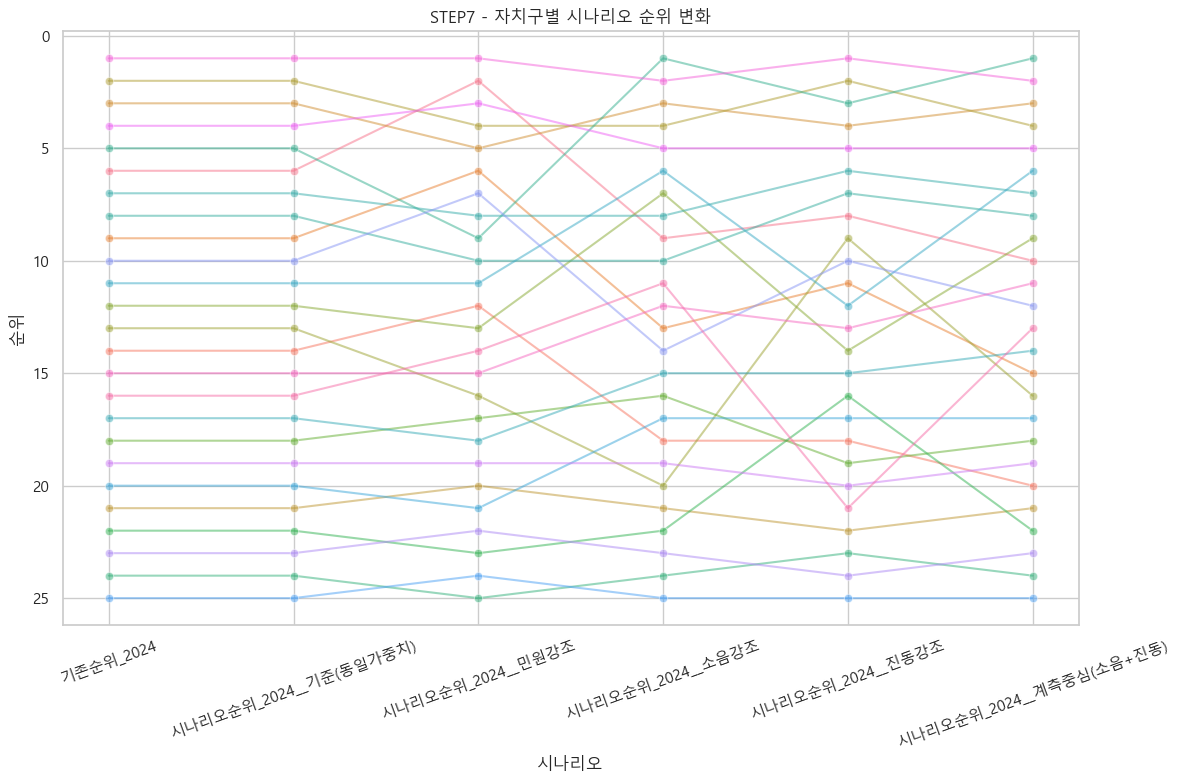

In [44]:
# sens_df가 있으면 사용
scenario_rank_cols = [c for c in sens_df.columns if c.startswith("시나리오순위_2024__")]
tmp = sens_df[["자치구", "기존순위_2024"] + scenario_rank_cols].copy()
long_s = tmp.melt(id_vars="자치구", var_name="시나리오", value_name="순위")

plt.figure(figsize=(12, 8))
sns.lineplot(data=long_s, x="시나리오", y="순위", hue="자치구", marker="o", legend=False, alpha=0.5)
plt.gca().invert_yaxis()
plt.title("STEP7 - 자치구별 시나리오 순위 변화")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## STEP 8. 최종 인사이트 정리 (보고서/발표용 자동 요약)

### 목적
- STEP 1~7 결과를 실제 보고/발표에 바로 쓸 수 있는 형태로 정리합니다.
- "무엇이 문제인지" + "어디부터 우선 대응할지"를 구조화합니다.


In [45]:
# 최종 보고용 기준 테이블 만들기
# 왜:
# - 여러 단계 결과를 한 테이블로 모아야 인사이트를 일관되게 설명할 수 있습니다.

# STEP 5에서 만든 change_df, STEP 6의 rank_df, STEP 7의 sens_df가 있다고 가정
# (없다면, 각 STEP 셀을 먼저 실행해 변수 생성)

report_df = df.copy()

# 변화량(있으면 merge)
if "change_df" in globals():
    use_cols = ["자치구", "증감_22_23", "증감_23_24", "증감률_22_23", "증감률_23_24", "추세_22_23", "추세_23_24"]
    use_cols = [c for c in use_cols if c in change_df.columns]
    report_df = report_df.merge(change_df[use_cols], on="자치구", how="left")

# 순위 안정성(있으면 merge)
if "rank_df" in globals():
    use_cols = ["자치구", "rank_2022", "rank_2023", "rank_2024", "rank_range_3y", "rank_volatility"]
    use_cols = [c for c in use_cols if c in rank_df.columns]
    report_df = report_df.merge(rank_df[use_cols], on="자치구", how="left")

# 민감도(있으면 merge)
if "sens_df" in globals():
    sens_cols = [c for c in sens_df.columns if c.startswith("순위변화__")]
    use_cols = ["자치구", "총민감도(절대변화합)"] + sens_cols
    use_cols = [c for c in use_cols if c in sens_df.columns]
    report_df = report_df.merge(sens_df[use_cols], on="자치구", how="left")

print("report_df shape:", report_df.shape)
display(report_df.head())


report_df shape: (25, 33)


,자치구,민원스트레스점수_2022,민원스트레스점수_2023,민원스트레스점수_2024,소음스트레스점수_2022,소음스트레스점수_2023,소음스트레스점수_2024,진동스트레스점수_2022,진동스트레스점수_2023,진동스트레스점수_2024,...,rank_2023,rank_2024,rank_range_3y,rank_volatility,총민감도(절대변화합),순위변화__기준(동일가중치),순위변화__민원강조,순위변화__소음강조,순위변화__진동강조,순위변화__계측중심(소음+진동)
0,종로구,6.09,6.98,6.52,3.36,3.20,3.52,3.96,4.16,4.73,...,4.0,6.0,6.0,8.0,13.0,0.0,4.0,-3.0,-2.0,-4.0
1,중구,8.00,4.44,4.25,3.03,2.13,2.34,2.63,2.96,4.37,...,15.0,14.0,7.0,8.0,16.0,0.0,2.0,-4.0,-4.0,-6.0
2,용산구,4.97,6.67,5.83,4.45,6.69,3.20,3.34,4.02,4.14,...,2.0,9.0,9.0,16.0,15.0,0.0,3.0,-4.0,-2.0,-6.0
3,성동구,3.49,4.33,4.16,6.29,8.00,6.66,3.87,4.62,5.09,...,3.0,3.0,6.0,6.0,3.0,0.0,-2.0,0.0,-1.0,0.0
4,광진구,2.13,1.90,1.78,4.94,3.40,2.68,4.25,4.73,4.82,...,13.0,21.0,8.0,9.0,2.0,0.0,1.0,0.0,-1.0,0.0


In [46]:
# 정책 우선순위 점수 만들기
# 왜:
# - 단순 총점만 보면 "지금 높지만 개선 중인 구"와 "빠르게 악화 중인 구"를 구분하기 어렵습니다.
# - 총점 수준 + 최근 악화 + 순위불안정 + 가중치민감도를 합쳐 우선순위 후보를 잡습니다.

import numpy as np

priority_df = report_df.copy()

# 안전장치: 필요한 컬럼 없으면 0으로 대체
for c in ["소음총점수_2024", "증감_23_24", "rank_volatility", "총민감도(절대변화합)"]:
    if c not in priority_df.columns:
        priority_df[c] = 0.0

# 표준화 함수
def zsafe(s):
    s = pd.to_numeric(s, errors="coerce")
    std = s.std()
    if std == 0 or pd.isna(std):
        return pd.Series(0, index=s.index)
    return (s - s.mean()) / std

# 우선순위 점수(가중치는 필요시 조정)
priority_df["우선순위점수"] = (
    0.45 * zsafe(priority_df["소음총점수_2024"]) +     # 현재 수준
    0.30 * zsafe(priority_df["증감_23_24"]) +          # 최근 악화 속도
    0.15 * zsafe(priority_df["rank_volatility"]) +     # 순위 불안정성
    0.10 * zsafe(priority_df["총민감도(절대변화합)"])   # 산식 민감도
)

priority_df = priority_df.sort_values("우선순위점수", ascending=False).reset_index(drop=True)
display(priority_df[["자치구", "소음총점수_2024", "증감_23_24", "rank_volatility", "총민감도(절대변화합)", "우선순위점수"]].head(10))


,자치구,소음총점수_2024,증감_23_24,rank_volatility,총민감도(절대변화합),우선순위점수
0,은평구,15.52,3.38,10.0,14.0,1.065475
1,동대문구,16.83,3.56,6.0,6.0,1.003219
2,강남구,19.51,0.68,0.0,2.0,0.645034
3,서초구,16.16,1.98,4.0,4.0,0.537175
4,강서구,12.71,2.41,12.0,11.0,0.498768
5,종로구,15.39,0.45,8.0,13.0,0.474226
6,서대문구,14.21,2.96,4.0,5.0,0.430660
7,성북구,12.18,2.91,9.0,11.0,0.403353
8,양천구,10.52,2.36,14.0,8.0,0.176384
9,성동구,16.57,-1.09,6.0,3.0,0.135922


In [47]:
# 구간(등급) 라벨링
# 왜:
# - 숫자만으로는 전달이 어렵기 때문에 High/Medium/Low 같은 구간 라벨을 붙여 설명력을 높입니다.

# 2024 총점 분위수 기반 4구간
priority_df["총점등급_2024"] = pd.qcut(
    priority_df["소음총점수_2024"],
    q=4,
    labels=["낮음", "중간", "높음", "매우높음"]
)

# 우선순위 점수 기반 3구간
priority_df["우선순위등급"] = pd.qcut(
    priority_df["우선순위점수"],
    q=3,
    labels=["관찰", "주의", "우선대응"]
)

display(priority_df[["자치구", "소음총점수_2024", "총점등급_2024", "우선순위점수", "우선순위등급"]].head(15))


,자치구,소음총점수_2024,총점등급_2024,우선순위점수,우선순위등급
0,은평구,15.52,매우높음,1.065475,우선대응
1,동대문구,16.83,매우높음,1.003219,우선대응
2,강남구,19.51,매우높음,0.645034,우선대응
3,서초구,16.16,매우높음,0.537175,우선대응
4,강서구,12.71,높음,0.498768,우선대응
5,종로구,15.39,매우높음,0.474226,우선대응
6,서대문구,14.21,높음,0.430660,우선대응
7,성북구,12.18,높음,0.403353,우선대응
8,양천구,10.52,중간,0.176384,주의
9,성동구,16.57,매우높음,0.135922,주의


In [48]:
# 보고서용 핵심 표 1: 우선대응 후보
# 왜:
# - 실무에서 가장 먼저 보는 표: "어디를 먼저 볼 것인가"

priority_top = priority_df.sort_values("우선순위점수", ascending=False)[
    ["자치구", "소음총점수_2024", "증감_23_24", "rank_2024", "rank_volatility", "우선순위점수", "우선순위등급"]
].head(10)

print("우선대응 후보 TOP 10")
display(priority_top)


우선대응 후보 TOP 10


,자치구,소음총점수_2024,증감_23_24,rank_2024,rank_volatility,우선순위점수,우선순위등급
0,은평구,15.52,3.38,5.0,10.0,1.065475,우선대응
1,동대문구,16.83,3.56,2.0,6.0,1.003219,우선대응
2,강남구,19.51,0.68,1.0,0.0,0.645034,우선대응
3,서초구,16.16,1.98,4.0,4.0,0.537175,우선대응
4,강서구,12.71,2.41,11.0,12.0,0.498768,우선대응
5,종로구,15.39,0.45,6.0,8.0,0.474226,우선대응
6,서대문구,14.21,2.96,8.0,4.0,0.430660,우선대응
7,성북구,12.18,2.91,12.0,9.0,0.403353,우선대응
8,양천구,10.52,2.36,17.0,14.0,0.176384,주의
9,성동구,16.57,-1.09,3.0,6.0,0.135922,주의


In [49]:
# 보고서용 핵심 표 2: 개선 벤치마크 후보
# 왜:
# - 개선된 구를 보면 확산 가능한 정책 힌트를 얻을 수 있습니다.

improve_candidates = priority_df.copy()

# 23→24 개선(음수) + 총점이 너무 낮지 않은 곳(중간 이상)을 예시 조건으로
improve_candidates = improve_candidates[
    (improve_candidates["증감_23_24"] < 0)
].sort_values("증감_23_24", ascending=True)

print("개선 벤치마크 후보 TOP 10 (감소폭 큰 순)")
display(improve_candidates[
    ["자치구", "소음총점수_2024", "증감_23_24", "rank_2024", "rank_volatility", "우선순위점수"]
].head(10))


개선 벤치마크 후보 TOP 10 (감소폭 큰 순)


,자치구,소음총점수_2024,증감_23_24,rank_2024,rank_volatility,우선순위점수
15,용산구,13.72,-4.38,9.0,16.0,-0.269294
24,금천구,7.65,-2.02,25.0,18.0,-0.974592
9,성동구,16.57,-1.09,3.0,6.0,0.135922
17,강동구,10.85,-0.95,16.0,9.0,-0.357689
22,광진구,9.67,-0.78,21.0,9.0,-0.751400


In [50]:
# 자동 인사이트 문장 생성(초안)
# 왜:
# - 발표자료/보고서 초안 작성 시간을 줄입니다.
# - 사람이 최종 문장만 다듬으면 됩니다.

top3 = priority_df.head(3)["자치구"].tolist()
improve3 = improve_candidates.head(3)["자치구"].tolist() if len(improve_candidates) > 0 else []

msg_1 = f"2024년 기준 종합 우선대응 후보 상위 지역은 {', '.join(top3)} 입니다."
msg_2 = "이 지역들은 총점 수준뿐 아니라 최근 변화(23→24), 순위 변동성, 가중치 민감도를 함께 고려했을 때 상대적으로 관리 우선순위가 높게 나타났습니다."
msg_3 = f"반대로 최근 개선 폭이 큰 지역은 {', '.join(improve3) if improve3 else '해당 없음'}으로 확인되어, 개선 요인의 벤치마크 검토 대상이 될 수 있습니다."

print(msg_1)
print(msg_2)
print(msg_3)


2024년 기준 종합 우선대응 후보 상위 지역은 은평구, 동대문구, 강남구 입니다.
이 지역들은 총점 수준뿐 아니라 최근 변화(23→24), 순위 변동성, 가중치 민감도를 함께 고려했을 때 상대적으로 관리 우선순위가 높게 나타났습니다.
반대로 최근 개선 폭이 큰 지역은 용산구, 금천구, 성동구으로 확인되어, 개선 요인의 벤치마크 검토 대상이 될 수 있습니다.


C:\Users\yiho1\AppData\Local\Temp\ipykernel_39128\2001499997.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_top, x="우선순위점수", y="자치구", palette="Reds_r")


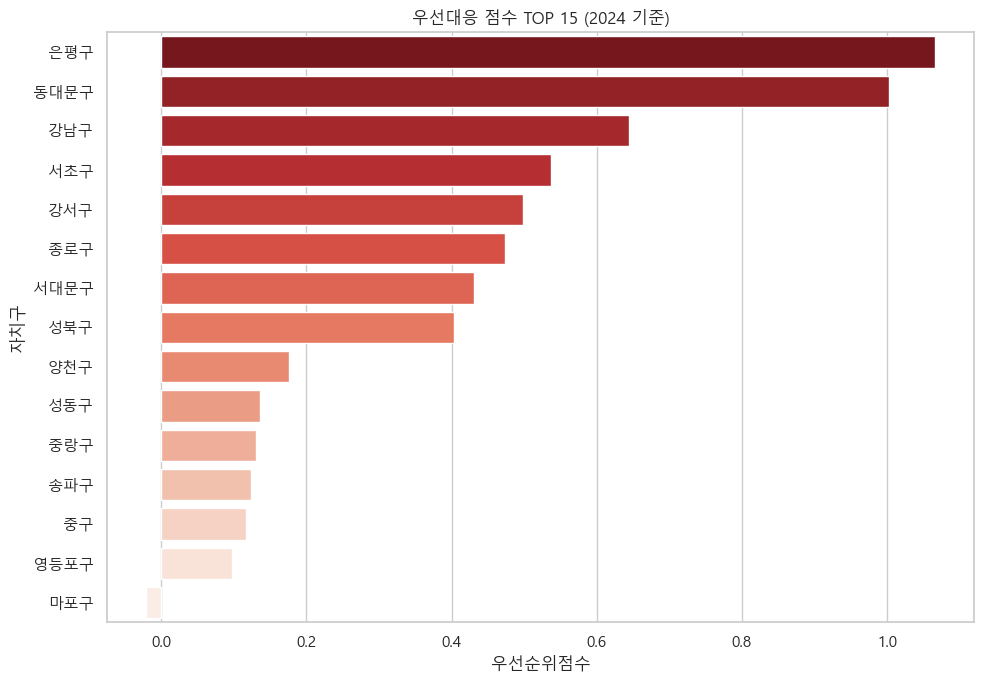

In [51]:
# 시각화: 우선순위 점수 Top 15
# 왜:
# - 최종 결과를 한 장으로 보여줄 수 있는 핵심 그래프

import matplotlib.pyplot as plt
import seaborn as sns

plot_top = priority_df.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=plot_top, x="우선순위점수", y="자치구", palette="Reds_r")
plt.title("우선대응 점수 TOP 15 (2024 기준)")
plt.xlabel("우선순위점수")
plt.ylabel("자치구")
plt.tight_layout()
plt.show()


In [52]:
# 최종 저장
# 왜:
# - 최종 결과를 파일로 남겨 재사용/공유 가능하게 합니다.

save_cols = [c for c in [
    "자치구",
    "소음총점수_2022", "소음총점수_2023", "소음총점수_2024",
    "증감_22_23", "증감_23_24", "증감률_22_23", "증감률_23_24",
    "rank_2022", "rank_2023", "rank_2024", "rank_range_3y", "rank_volatility",
    "총민감도(절대변화합)",
    "우선순위점수", "총점등급_2024", "우선순위등급"
] if c in priority_df.columns]

final_report = priority_df[save_cols].copy()
final_report.to_csv("소음EDA_최종리포트_2024기준.csv", index=False, encoding="utf-8-sig")

print("저장 완료: 소음EDA_최종리포트_2024기준.csv")
display(final_report.head())


저장 완료: 소음EDA_최종리포트_2024기준.csv


,자치구,소음총점수_2022,소음총점수_2023,소음총점수_2024,증감_22_23,증감_23_24,증감률_22_23,증감률_23_24,rank_2022,rank_2023,rank_2024,rank_range_3y,rank_volatility,총민감도(절대변화합),우선순위점수,총점등급_2024,우선순위등급
0,은평구,14.88,12.14,15.52,-2.74,3.38,-18.413978,27.841845,3.0,9.0,5.0,6.0,10.0,14.0,1.065475,매우높음,우선대응
1,동대문구,14.41,13.27,16.83,-1.14,3.56,-7.911173,26.827430,6.0,7.0,2.0,5.0,6.0,6.0,1.003219,매우높음,우선대응
2,강남구,19.21,18.83,19.51,-0.38,0.68,-1.978136,3.611259,1.0,1.0,1.0,0.0,0.0,2.0,0.645034,매우높음,우선대응
3,서초구,15.58,14.18,16.16,-1.40,1.98,-8.985879,13.963329,2.0,5.0,4.0,3.0,4.0,4.0,0.537175,매우높음,우선대응
4,강서구,14.46,10.30,12.71,-4.16,2.41,-28.769018,23.398058,5.0,14.0,11.0,9.0,12.0,11.0,0.498768,높음,우선대응


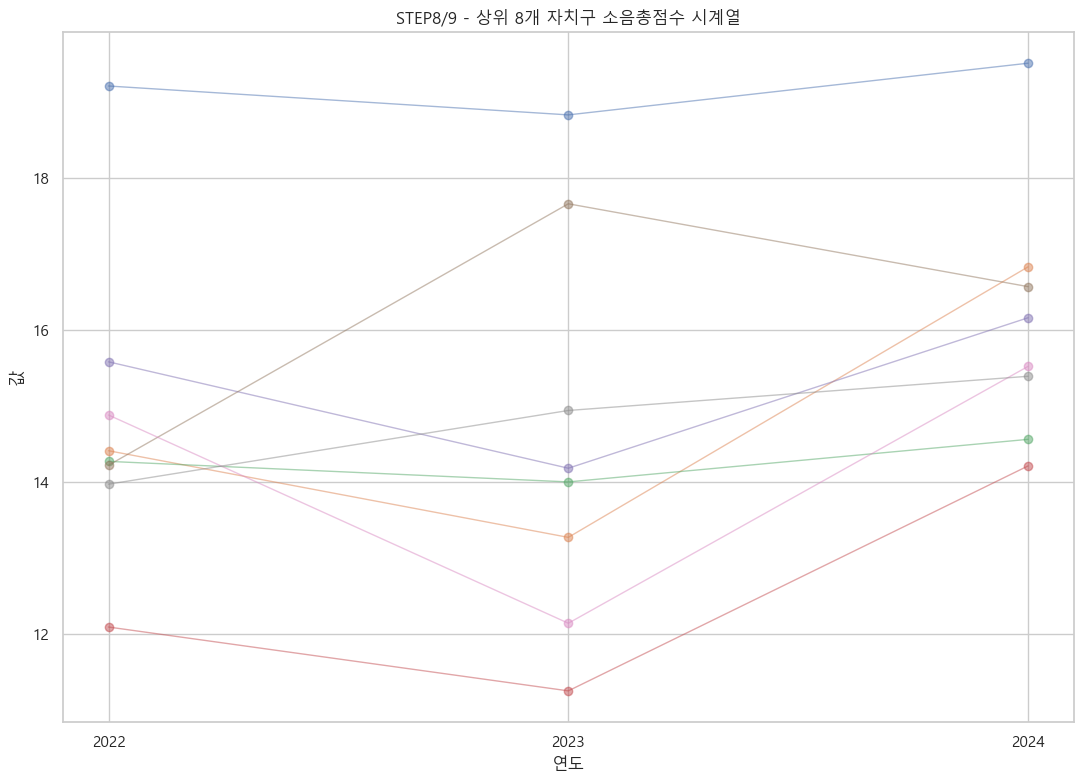

In [53]:
# 너무 복잡하면 상위 N개 구만 보기
topN = 8
top_gu = df.sort_values("소음총점수_2024", ascending=False).head(topN)["자치구"]

focus = df[df["자치구"].isin(top_gu)].copy()
plot_gu_timeseries(
    focus,
    value_prefix="소음총점수_",
    title=f"STEP8/9 - 상위 {topN}개 자치구 소음총점수 시계열"
)


## STEP 9. 자치구별 문제유형 진단 EDA

### 목적
- 총점이 높은 이유를 자치구별로 분해해서 봅니다.
- "어떤 문제가 큰지"를 유형으로 라벨링해 정책 포인트를 잡습니다.


In [54]:
# 2024 기준 구성요소 분해 테이블 준비
# 왜:
# - 총점만으로는 원인이 안 보이므로 민원/소음/진동을 나눠 봐야 합니다.

diag_df = df.copy()

cols_2024 = [
    "자치구",
    "민원스트레스점수_2024",
    "소음스트레스점수_2024",
    "진동스트레스점수_2024",
    "소음총점수_2024",
]
diag_df = diag_df[cols_2024].copy()
display(diag_df.head())


,자치구,민원스트레스점수_2024,소음스트레스점수_2024,진동스트레스점수_2024,소음총점수_2024
0,종로구,6.52,3.52,4.73,15.39
1,중구,4.25,2.34,4.37,11.42
2,용산구,5.83,3.20,4.14,13.72
3,성동구,4.16,6.66,5.09,16.57
4,광진구,1.78,2.68,4.82,9.67


In [55]:
# 각 자치구에서 어떤 축이 가장 큰지(주요 원인) 라벨링
# 왜:
# - "이 구는 소음형 문제", "이 구는 민원형 문제"처럼 직관적으로 설명 가능

comp_cols = ["민원스트레스점수_2024", "소음스트레스점수_2024", "진동스트레스점수_2024"]
name_map = {
    "민원스트레스점수_2024": "민원형",
    "소음스트레스점수_2024": "소음형",
    "진동스트레스점수_2024": "진동형",
}

diag_df["주요문제축"] = diag_df[comp_cols].idxmax(axis=1).map(name_map)
diag_df["최대축점수"] = diag_df[comp_cols].max(axis=1)
diag_df["최소축점수"] = diag_df[comp_cols].min(axis=1)
diag_df["축간격차"] = diag_df["최대축점수"] - diag_df["최소축점수"]  # 클수록 특정 축 쏠림

display(diag_df.sort_values("소음총점수_2024", ascending=False).head(10))


,자치구,민원스트레스점수_2024,소음스트레스점수_2024,진동스트레스점수_2024,소음총점수_2024,주요문제축,최대축점수,최소축점수,축간격차
22,강남구,8.00,5.80,4.93,19.51,민원형,8.00,4.93,3.07
5,동대문구,4.55,5.56,6.05,16.83,진동형,6.05,4.55,1.50
3,성동구,4.16,6.66,5.09,16.57,소음형,6.66,4.16,2.50
21,서초구,5.41,4.92,5.18,16.16,민원형,5.41,4.92,0.49
11,은평구,1.23,8.00,5.67,15.52,소음형,8.00,1.23,6.77
0,종로구,6.52,3.52,4.73,15.39,민원형,6.52,3.52,3.00
13,마포구,3.49,4.09,6.40,14.56,진동형,6.40,3.49,2.91
12,서대문구,3.12,3.99,6.53,14.21,진동형,6.53,3.12,3.41
2,용산구,5.83,3.20,4.14,13.72,민원형,5.83,3.20,2.63
18,영등포구,5.09,3.16,4.91,13.71,민원형,5.09,3.16,1.93


In [56]:
# 복합형(여러 축이 동시에 높음) 구분
# 왜:
# - 단일 원인형과 복합형을 나눠야 대응 방식이 달라집니다.

# 기준: 축간격차가 작고, 평균 수준이 높은 경우를 복합형으로 간주
q_gap = diag_df["축간격차"].quantile(0.40)      # 하위 40%면 축이 비슷
q_mean = diag_df[comp_cols].mean(axis=1).quantile(0.70)  # 상위 30%면 전반적으로 높음

diag_df["평균구성점수"] = diag_df[comp_cols].mean(axis=1)
diag_df["문제유형"] = diag_df["주요문제축"]

diag_df.loc[
    (diag_df["축간격차"] <= q_gap) & (diag_df["평균구성점수"] >= q_mean),
    "문제유형"
] = "복합형"

print("유형 분포")
print(diag_df["문제유형"].value_counts())
display(diag_df[["자치구", "문제유형", "평균구성점수", "축간격차", "소음총점수_2024"]].head())


유형 분포
문제유형
진동형    14
민원형     4
소음형     4
복합형     3
Name: count, dtype: int64


,자치구,문제유형,평균구성점수,축간격차,소음총점수_2024
0,종로구,민원형,4.923333,3.00,15.39
1,중구,진동형,3.653333,2.03,11.42
2,용산구,민원형,4.390000,2.63,13.72
3,성동구,복합형,5.303333,2.50,16.57
4,광진구,진동형,3.093333,3.04,9.67


In [57]:
# 유형별 자치구 목록 + 총점 평균
# 왜:
# - 유형별 특징(어느 유형이 더 심한지) 파악

type_summary = diag_df.groupby("문제유형", as_index=False).agg(
    자치구수=("자치구", "count"),
    총점평균=("소음총점수_2024", "mean"),
    민원평균=("민원스트레스점수_2024", "mean"),
    소음평균=("소음스트레스점수_2024", "mean"),
    진동평균=("진동스트레스점수_2024", "mean"),
)
display(type_summary.sort_values("총점평균", ascending=False))

for t in diag_df["문제유형"].unique():
    print(f"\n[{t}]")
    print(", ".join(diag_df.loc[diag_df["문제유형"] == t, "자치구"].tolist()))


,문제유형,자치구수,총점평균,민원평균,소음평균,진동평균
1,복합형,3,16.520000,4.706667,5.713333,5.440000
0,민원형,4,15.582500,6.360000,3.920000,4.677500
2,소음형,4,12.815000,2.112500,6.095000,4.095000
3,진동형,14,10.571429,2.072857,2.890000,5.185714



[민원형]
종로구, 용산구, 영등포구, 강남구

[진동형]
중구, 광진구, 중랑구, 강북구, 도봉구, 노원구, 서대문구, 마포구, 양천구, 구로구, 금천구, 동작구, 관악구, 송파구

[복합형]
성동구, 동대문구, 서초구

[소음형]
성북구, 은평구, 강서구, 강동구


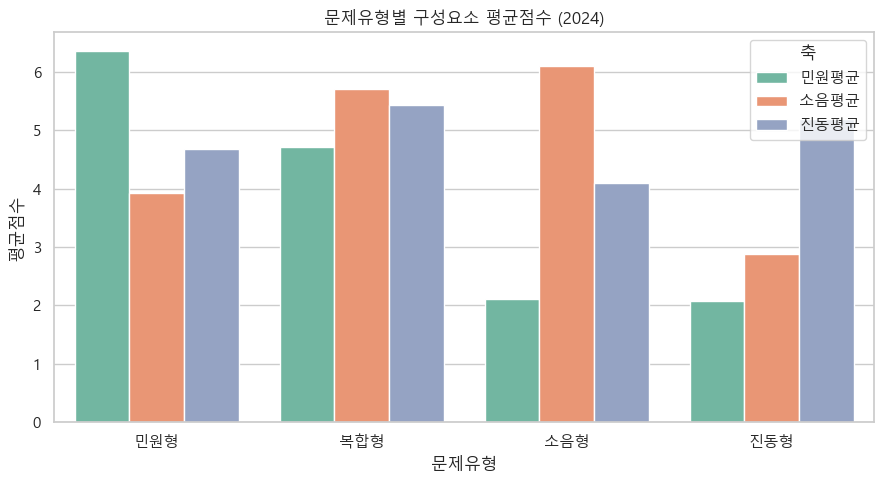

In [58]:
# 레이더 대체 시각화(유형별 평균 막대)
# 왜:
# - 발표 시 유형별로 무엇이 큰지 한눈에 비교 가능

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_type = type_summary.melt(
    id_vars="문제유형",
    value_vars=["민원평균", "소음평균", "진동평균"],
    var_name="축",
    value_name="평균점수"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_type, x="문제유형", y="평균점수", hue="축", palette="Set2")
plt.title("문제유형별 구성요소 평균점수 (2024)")
plt.xlabel("문제유형")
plt.ylabel("평균점수")
plt.tight_layout()
plt.show()


In [59]:
# 자치구별 처방 힌트 자동 생성(초안)
# 왜:
# - EDA 결과를 바로 실행 가능한 문장으로 연결

def suggest_action(row):
    t = row["문제유형"]
    if t == "민원형":
        return "생활소음 민원 다발 시간대/지점 집중관리, 민원 핫스팟 단속 강화"
    if t == "소음형":
        return "상시 소음원(도로·공사·상업지역) 저감 중심의 구조적 대책 우선"
    if t == "진동형":
        return "진동원(중장비·교통축) 점검 및 방진 대책 우선"
    return "복합형 대응(민원+소음+진동 동시관리), 부서 합동 패키지 대책 권장"

diag_df["권장대응"] = diag_df.apply(suggest_action, axis=1)

display(
    diag_df.sort_values("소음총점수_2024", ascending=False)[
        ["자치구", "문제유형", "소음총점수_2024", "민원스트레스점수_2024", "소음스트레스점수_2024", "진동스트레스점수_2024", "권장대응"]
    ].head(15)
)


,자치구,문제유형,소음총점수_2024,민원스트레스점수_2024,소음스트레스점수_2024,진동스트레스점수_2024,권장대응
22,강남구,민원형,19.51,8.00,5.80,4.93,"생활소음 민원 다발 시간대/지점 집중관리, 민원 핫스팟 단속 강화"
5,동대문구,복합형,16.83,4.55,5.56,6.05,"복합형 대응(민원+소음+진동 동시관리), 부서 합동 패키지 대책 권장"
3,성동구,복합형,16.57,4.16,6.66,5.09,"복합형 대응(민원+소음+진동 동시관리), 부서 합동 패키지 대책 권장"
21,서초구,복합형,16.16,5.41,4.92,5.18,"복합형 대응(민원+소음+진동 동시관리), 부서 합동 패키지 대책 권장"
11,은평구,소음형,15.52,1.23,8.00,5.67,상시 소음원(도로·공사·상업지역) 저감 중심의 구조적 대책 우선
0,종로구,민원형,15.39,6.52,3.52,4.73,"생활소음 민원 다발 시간대/지점 집중관리, 민원 핫스팟 단속 강화"
13,마포구,진동형,14.56,3.49,4.09,6.40,진동원(중장비·교통축) 점검 및 방진 대책 우선
12,서대문구,진동형,14.21,3.12,3.99,6.53,진동원(중장비·교통축) 점검 및 방진 대책 우선
2,용산구,민원형,13.72,5.83,3.20,4.14,"생활소음 민원 다발 시간대/지점 집중관리, 민원 핫스팟 단속 강화"
18,영등포구,민원형,13.71,5.09,3.16,4.91,"생활소음 민원 다발 시간대/지점 집중관리, 민원 핫스팟 단속 강화"


월별로 보는거도 좋을거같다
그래프 라인보다 바
자치구별 진동 상관 민원과 진동 상관 소음과 진동 --> 진동에 따라 소음이 발생하냐같은 상관이 보일거같다
소음으로 자치구별로 다른가? 소음이 클때 진동은 어떤지 여튼 자치구별로 다른지, 서로서로의 카테고리별로의 상관
민원에 기존과 인구비례를 따로 볼 필요가 있음
